# Run entire notebook to generate all results for dissertation

In [1]:
import re
import dcor
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.neighbors import KernelDensity
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse.csgraph import connected_components, shortest_path

import plot_style as ps

In [2]:
LINEAR_COLOUR = "red" # maybe could use import matplotlib.patheffects as pe to outline lines if necessary
ORDINARY_COLOUR = "orange"
DENSITY_COLOUR = "black"
PCA_COLOUR = "blue"
OBSERVED_COLOUR = "green"

colour_map = {
    "density_aware": DENSITY_COLOUR,
    "ordinary_graph": ORDINARY_COLOUR,
    "linear": LINEAR_COLOUR,
    "PCA": PCA_COLOUR,
    "observed": OBSERVED_COLOUR
}

TITLE_FONTSIZE = 18
LABEL_FONTSIZE = 14
TICK_FONTSIZE = 14
LEGEND_FONTSIZE = 14
SUPTITLE_FONTSIZE = 18
GRID_ALPHA = 0.3
LINEWIDTH = 3

plt.rcParams.update({
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "figure.titlesize": SUPTITLE_FONTSIZE,
    "lines.linewidth": LINEWIDTH
})

#### Constants

In [3]:
K_GRAPH = 15
BETA = 1.5
N_DIFFUSION_COORDS = 4
EPS_DIFFUSION = 3
M_LIFT = 16

endpoint_pairs = {"1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01"), 
                  "2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"),
                  "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2022 Monetary Tightening": ("2019-04-01", "2022-04-01")}

#### Functions

In [4]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

    
def lnl_error(Psi, Z, m, tau):
    N = len(Z); Z_hat = np.zeros_like(Z, dtype=float)

    for i in range(N):
        mask = np.arange(N) != i
        nn = NearestNeighbors(n_neighbors=m).fit(Psi[mask])
        distances, indices = nn.kneighbors(Psi[i:i+1])

        d2 = distances[0]**2; weights = np.exp(-(d2 - d2.min()) / tau)
        weights /= weights.sum(); Z_hat[i] = weights @ Z[mask][indices[0]]

    residual = Z - Z_hat; residual_ss = np.sum(residual**2)
    total_ss = np.sum((Z - Z.mean(axis=0))**2)

    return {"lift_RMSE": np.sqrt(np.mean(residual**2)), 
            "rms_observation_error": np.sqrt(np.mean(np.sum(residual**2, axis=1))), 
            "variance_recovered": 1 - residual_ss / total_ss}

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def interior_values(x):
    x = np.asarray(x)
    if len(x) > 2:
        return x[1:-1]
    return x

def density_aware_cost(A_dist_sym, V, beta):
    A_weight = A_dist_sym.astype(float).tocsr()
    rows, cols = A_weight.nonzero()
    A_weight.data *= np.exp(beta * 0.5 * (V[rows] + V[cols]))
    return A_weight

def reconstruct_path(predecessors, start, end):
    path = [end]; current = end
    while current != start:
        if predecessors.ndim == 1:
            current = predecessors[current]
        else:
            current = predecessors[start, current]
        if current == -9999: return None
        path.append(current)
    return np.array(path[::-1], dtype=int)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, predecessors = shortest_path(A, directed=False, indices=start, return_predecessors=True)
    return reconstruct_path(predecessors, start, end)

def linear_path(Psi, start_idx, end_idx, n_grid=10):
    return np.linspace(Psi[start_idx], Psi[end_idx], num=n_grid)

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1) / scale
    rho_query = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query)
    return rho_query, V_query


def loo_graph_density(indices, Psi, h, scale):
    rho_out = np.zeros(len(indices))
    V_out = np.zeros(len(indices))
    for pos, idx in enumerate(indices):
        mask = np.ones(len(Psi), dtype=bool)
        mask[idx] = False
        rho_i, V_i = latent_density_at_points(Psi[idx:idx+1], Psi[mask], h, scale)
        rho_out[pos] = rho_i[0]
        V_out[pos] = V_i[0]
    return rho_out, V_out


def local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=27, tau=0.2):
    nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi)
    distances, indices = nn.kneighbors(gamma)
    a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
    points = Z[indices, :]; z_hat = np.sum(a[:, :, None] * points, axis=1)
    z_hat[0], z_hat[-1] = Z[start_idx], Z[end_idx]
    return z_hat

#### Loading data

In [5]:
df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]

obs_df = pd.read_parquet("./datasets/transformed_observed_df.parquet").loc[dates]
Z_real = obs_df[variables].to_numpy()

pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}
diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]

h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)


# 6.1 Empirical embedding results
### Spectrum of the transition matrix for different bandwidths

In [6]:
epss = [1, 2, 3, 4, 5]

trials = len(epss); N = Z.shape[0]; k = 7
Psis = np.zeros((trials, N, k)); Ws = np.zeros((trials, N, N)); evals = []; qs = []

for i, eps in enumerate(epss):
    diff = diffusion_map(Z, eps=eps, k=k)

    Psis[i] = diff["Psi"]; Ws[i] = diff["W"]
    evals.append(diff["evals"][1:15])
    qs.append(diff["degrees"])

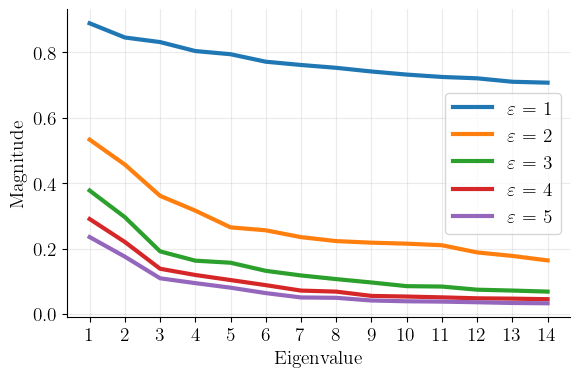

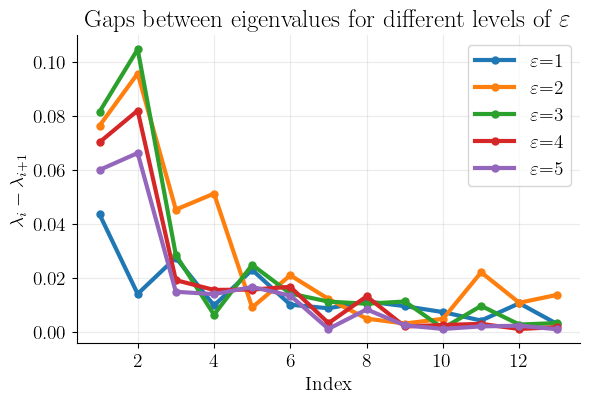

In [7]:
fig, ax1 = plt.subplots(figsize=ps.FIG_SINGLE_WD)
for i, w in enumerate(evals):
    ax1.plot(np.arange(1, len(w)+1), w, label=fr"$\varepsilon$ = {epss[i]}")
ax1.set_xticks(range(1,15))
ax1.set_xlabel("Eigenvalue"); ax1.set_ylabel("Magnitude")
ax1.legend()
plt.show()

fig, ax2 = plt.subplots(figsize=ps.FIG_SINGLE_WD)
gaps = [e[:-1] - e[1:] for e in evals]
for eps, gap in zip(epss, gaps):
    ax2.plot(np.arange(1, len(gap)+1), gap, marker="o", label=fr"$\varepsilon$={eps}")

ax2.set_title(r"Gaps between eigenvalues for different levels of $\varepsilon$")
ax2.set_xlabel("Index")
ax2.set_ylabel(r"$\lambda_i-\lambda_{i+1}$")
ax2.legend()
plt.show()


### Minimum degree and degree CV across bandwidths

In [8]:
rows = []; mins = []

for i, q in enumerate(qs):
    rows.append({"eps": epss[i],"mean": np.mean(q), "Std": np.std(q), "Min": np.min(q), "degree CV": q.std() / q.mean(), "mean OD affinity": (Ws[i].sum() - N) / (N * (N - 1))})

degree_df = pd.DataFrame(rows)
degree_df

,eps,mean,Std,Min,degree CV,mean OD affinity
0,1,7.486627,3.509202,1.445262,0.468729,0.008742
1,2,51.728818,17.262012,9.521181,0.333702,0.068368
2,3,114.304416,28.686223,31.240406,0.250963,0.152701
3,4,175.407510,35.332740,62.454251,0.201432,0.235051
4,5,229.401009,38.635636,97.648770,0.168420,0.307818


### Justification of embedding dimension
#### Variance recovered

In [9]:
R_VALUES = [2, 3, 4, 5]
diff_full = diffusion_map(Z, eps=EPS_DIFFUSION, k=max(R_VALUES))
Psi_full = diff_full["Psi"]

dimension_rows, path_rows, dimension_store = [], [], {}

for r in R_VALUES:
    Psi_r = Psi_full[:, :r]
    h_r, med_Dsq_r, (rho_r, V_r, scale_r) = density_and_bandwidth(Psi_r)

    A_r = kneighbors_graph(Psi_r, n_neighbors=K_GRAPH, mode="distance", include_self=False)
    A_r_sym = A_r.maximum(A_r.T)

    reconstruction = lnl_error(Psi_r, Z, m=M_LIFT, tau=med_Dsq_r)
    degree_r = np.asarray((A_r_sym > 0).sum(axis=1)).ravel()
    n_components_r = connected_components(A_r_sym, directed=False, return_labels=False)

    dimension_rows.append({"r": r, "lift_RMSE": reconstruction["lift_RMSE"], "variance_recovered_%": 100 * reconstruction["variance_recovered"],
                           "connected_components": n_components_r, "mean_degree": degree_r.mean(), "mean_edge_length": A_r_sym.data.mean(),
                           "median_edge_length": np.median(A_r_sym.data), "density_bandwidth": h_r})


dimension_table = pd.DataFrame(dimension_rows)
display(dimension_table.round(4))


,r,lift_RMSE,variance_recovered_%,connected_components,mean_degree,mean_edge_length,median_edge_length,density_bandwidth
0,2,0.2430,29.2778,1,17.6985,0.0327,0.0262,0.0043
1,3,0.2284,37.5681,1,18.7672,0.0606,0.0515,0.0052
2,4,0.2155,44.4221,1,19.1521,0.0801,0.0725,0.0061
3,5,0.2111,46.6454,1,19.3459,0.0893,0.0806,0.0066


#### Near-collision statistics

In [10]:
def collision_diagnostic(Psi_full, dates=None, base_dims=(2, 3, 4), collision_quantile=0.01, min_index_gap=12):
    n = len(Psi_full)
    i_all, j_all = np.triu_indices(n, k=1)

    keep = np.abs(i_all - j_all) > min_index_gap
    i, j = i_all[keep], j_all[keep]

    summaries, pair_tables = [], {}

    for base_dim in base_dims:
        base_distance = np.linalg.norm(Psi_full[i, :base_dim] - Psi_full[j, :base_dim], axis=1)
        new_distance = np.linalg.norm(Psi_full[i, :base_dim+1] - Psi_full[j, :base_dim+1], axis=1)

        added_separation = np.abs(Psi_full[i, base_dim] - Psi_full[j, base_dim])
        added_sd = np.std(Psi_full[:, base_dim], ddof=1)
        added_separation_std = added_separation / max(added_sd, 1e-12)

        collision_threshold = np.quantile(base_distance, collision_quantile)
        near_collision = base_distance <= collision_threshold

        new_quantiles = [0.01, 0.05, 0.10]; leaving_threshold = []
        for quantile in new_quantiles:
            new_threshold = np.quantile(new_distance, quantile)
            fraction_above_threshold = np.mean(new_distance[near_collision] > new_threshold)
            leaving_threshold.append(fraction_above_threshold * 100)

        all_median = np.median(added_separation_std)
        near_values = added_separation_std[near_collision]

        summaries.append({"comparison": f"{base_dim}D -> {base_dim + 1}D", "collision_distance_threshold": collision_threshold,
                          "number_near_collisions": near_collision.sum(), "percent_leaving_bottom_1pct": leaving_threshold[0],
                          "percent_leaving_bottom_5pct": leaving_threshold[1], "percent_leaving_bottom_10pct": leaving_threshold[2],
                          "median_added_separation_SD": np.median(near_values), "all_pairs_median_added_separation_SD": all_median})

        pair_table = pd.DataFrame({"i": i, "j": j, "base_distance": base_distance, "new_distance": new_distance,
                                    "added_separation": added_separation, "added_separation_SD": added_separation_std,
                                    "near_collision": near_collision})

        if dates is not None:
            date_array = np.asarray(dates)
            pair_table["date_i"] = date_array[i]
            pair_table["date_j"] = date_array[j]

        pair_tables[base_dim] = pair_table

    return pd.DataFrame(summaries), pair_tables

In [11]:
collision_summary, collision_pairs = collision_diagnostic(Psi_full, dates=dates, base_dims=(2, 3, 4), collision_quantile=0.01, min_index_gap=12)
display(collision_summary.round(2))

,comparison,collision_distance_threshold,number_near_collisions,percent_leaving_bottom_1pct,percent_leaving_bottom_5pct,percent_leaving_bottom_10pct,median_added_separation_SD,all_pairs_median_added_separation_SD
0,2D -> 3D,0.02,2669,62.27,36.87,24.39,0.83,0.92
1,3D -> 4D,0.05,2669,52.23,25.63,14.28,0.96,0.99
2,4D -> 5D,0.07,2669,20.87,1.61,0.26,0.47,0.85


### Diffusion coordinate meanings

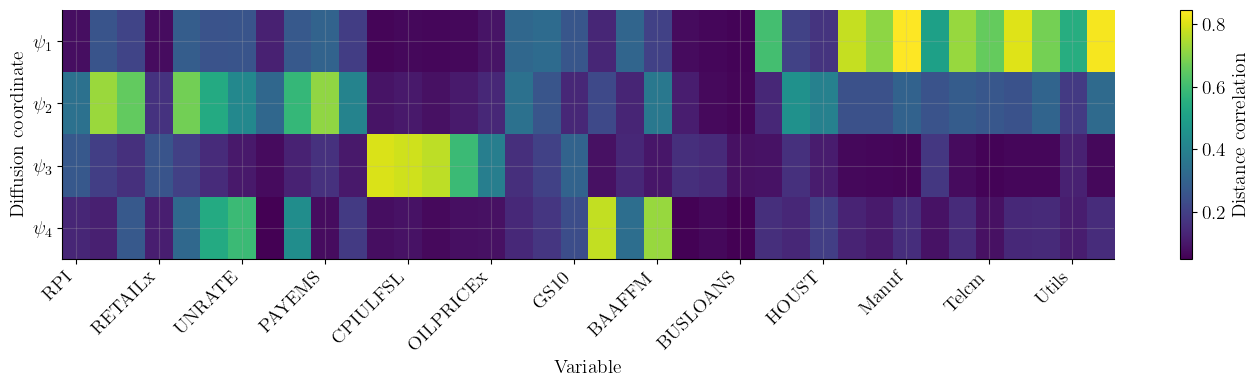

,p_1_feature,p_1_dcor,p_2_feature,p_2_dcor,p_3_feature,p_3_dcor,p_4_feature,p_4_dcor
0,Manuf,0.845082,W875RX1,0.724426,CPIAUCSL,0.799235,T10YFFM,0.771738
1,Other,0.835480,PAYEMS,0.714456,CPIULFSL,0.788319,BAAFFM,0.723275
2,Shops,0.806298,INDPRO,0.674454,PCEPI,0.766656,UNRATE,0.590993
3,NoDur,0.775023,DPCERA3M086SBEA,0.654486,WPSID61,0.592390,CUMFNS,0.536247
4,HiTec,0.722096,CLAIMSx,0.578161,OILPRICEx,0.389817,CLAIMSx,0.441536
5,Durbl,0.710173,CUMFNS,0.537488,GS10,0.302517,BAA,0.338309
6,Hlth,0.679495,VIXCLSx,0.453101,RPI,0.268494,INDPRO,0.319580
7,Telcm,0.656330,UNRATE,0.419968,RETAILx,0.257599,DPCERA3M086SBEA,0.273832
8,S&P PE ratio,0.606773,AWHMAN,0.405318,GS1,0.203700,GS10,0.239108
9,Utils,0.546941,HOUST,0.399120,INDPRO,0.201589,HOUST,0.197862


In [12]:
dcor_matrix = pd.DataFrame(index=variables, columns=[rf"$\psi_{i+1}$" for i in range(Psi.shape[1])], dtype=float)

for var in variables:
    for k in range(Psi.shape[1]):
        dcor_matrix.loc[var, rf"$\psi_{k+1}$"] = dcor.distance_correlation(df[var].to_numpy(), Psi[:, k])

fig, ax = plt.subplots(figsize=(14, 4))
c = ax.imshow(dcor_matrix.T, aspect='auto')

ax.set_yticks([0, 1, 2, 3]); ax.set_yticklabels([r"$\psi_1$", r"$\psi_2$", r"$\psi_3$", r"$\psi_4$"])
ax.set_ylabel("Diffusion coordinate")

step_size = 3
x_positions = np.arange(0, len(variables), step_size); x_labels = list(variables)[::step_size]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_xlabel("Variable")

fig.colorbar(c, ax=ax, label="Distance correlation"); plt.tight_layout(); plt.show()

top10_dict = {}
for col in dcor_matrix.columns:
    top10 = dcor_matrix[col].sort_values(ascending=False).head(10)
    p_num = re.search(r'\d+', col).group()
    top10_dict[f"p_{p_num}_feature"] = top10.index
    top10_dict[f"p_{p_num}_dcor"] = top10.values

top_dcor = pd.DataFrame(top10_dict)
top_dcor

### Embedding coloured by variable

In [15]:
def plot_2d(Psi, colour=None, title="Unknown", cbar_title="Unknown", dims=(1,2), figsize=(8,8), save=None):
    x, y = dims
    if colour is None:
        colour = np.arange(len(Psi))

    fig = plt.figure(figsize=figsize)    
    ax1 = fig.add_subplot() 
    
    ax1.set_xlabel(rf"$\psi_{x}$"); ax1.set_ylabel(rf"$\psi_{y}$")
    ax1.set_title(f"2D embedding coloured by {title}")
    c = ax1.scatter(Psi[:, x-1], Psi[:, y-1], c=colour[:], s=20, cmap="viridis")

    plt.colorbar(c, ax=ax1, label=f'{cbar_title} (Quantile)')


    plt.tight_layout()
    if save is not None:
        if save.split(".")[-1] == "pdf":
            plt.savefig(save)
        else:
            plt.savefig(save, dpi=300, bbox_inches='tight')
    plt.show()

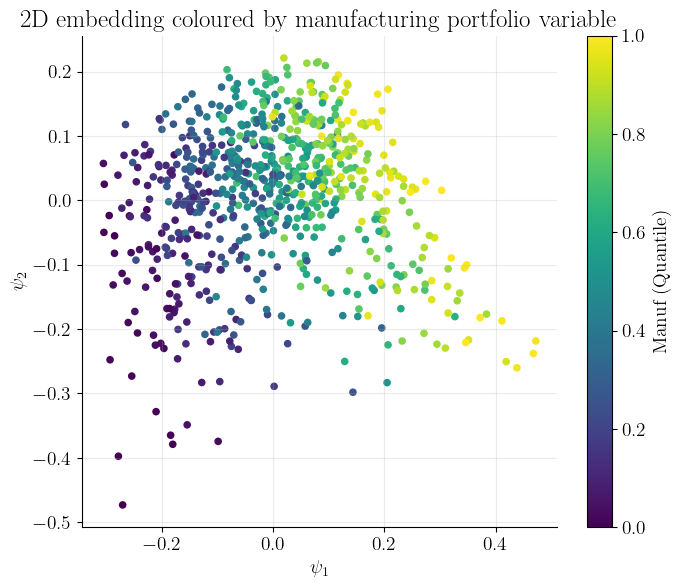

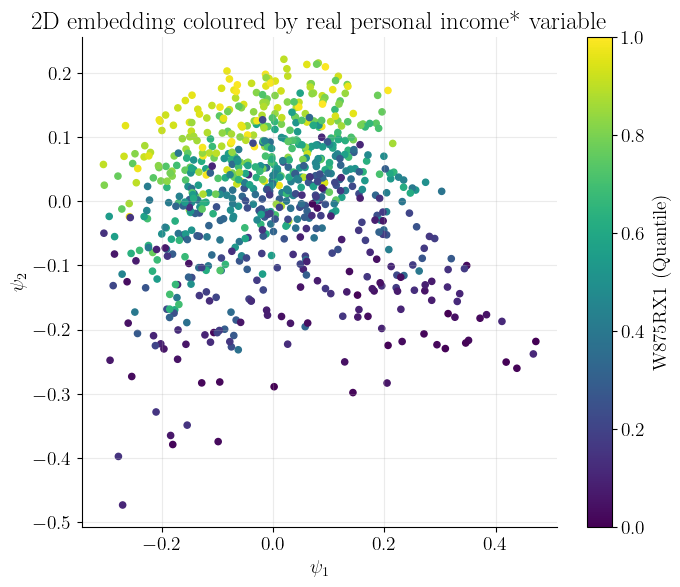

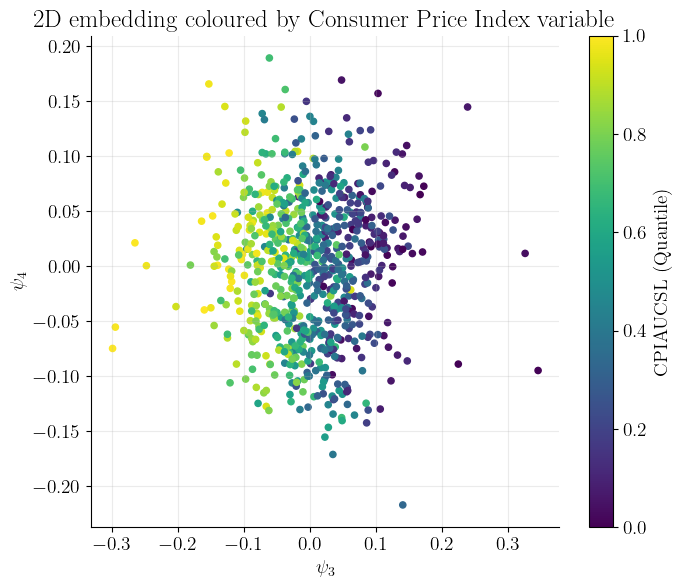

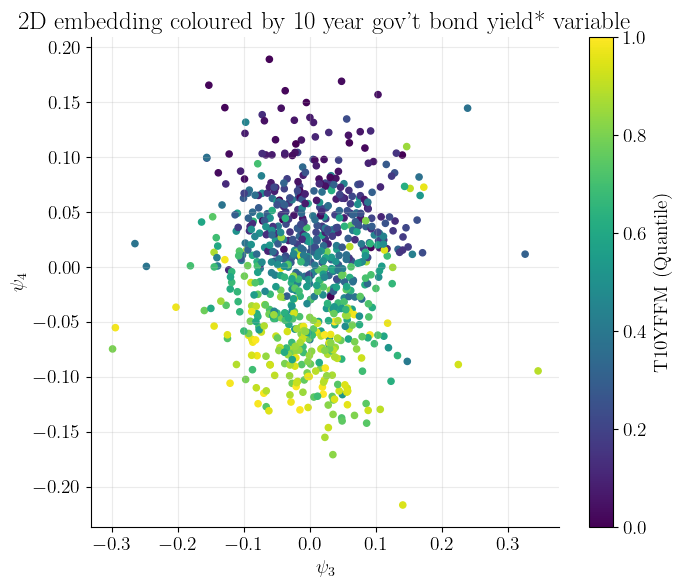

In [ ]:
coord_vars = {"Manuf": (1,2), "W875RX1": (1, 2), "CPIAUCSL": (3, 4), "T10YFFM": (3, 4)}
variable_translations = {
    "Manuf": "manufacturing portfolio",
    "W875RX1": "real personal income*",
    "CPIAUCSL": "Consumer Price Index",
    "T10YFFM": "10 year gov't bond yield*"
}

for var, dims in coord_vars.items():
    plot_2d(Psi, df[var], title=f'{variable_translations.get(var, var)} variable', cbar_title=var, dims=dims, figsize=(ps.FIG_SINGLE_SQ[0]+1, ps.FIG_SINGLE_SQ[1]), save=f"./figures/embedding_coloured_by_{var}_2d.pdf")

# 6.2 Embedding density results
### $k\text{NN}$ graph metrics by $k$

In [ ]:
def knn_graph_checks(Psi, k, sample_skip=5, jump_thresh=8.0):
    N = Psi.shape[0]
    A_dist = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
    A_bin  = kneighbors_graph(Psi, n_neighbors=k, mode="connectivity", include_self=False)
    A_dist_sym = A_dist.maximum(A_dist.T); A_bin_sym = A_bin.maximum(A_bin.T)
    n_comp, _ = connected_components(A_bin_sym, directed=False)
    degree = np.asarray(A_bin_sym.sum(1)).ravel()
    edges = A_bin_sym.nnz/2; density = edges/(N*(N-1)/2)
    _, pred = shortest_path(A_dist_sym, directed=False, return_predecessors=True)
    jr = []
    for a in range(1, N, sample_skip):
        for b in range(a+1, N, sample_skip):
            path = reconstruct_path(pred, a, b)
            if path is None or len(path) < 2: continue
            el = np.array([A_dist_sym[path[t], path[t+1]] for t in range(len(path)-1)])  # [C7] renamed t
            med = np.median(el)
            if med > 1e-12: jr.append(el.max()/med)
    jr = np.array(jr); jr95 = np.quantile(jr, 0.95)
    accept = (n_comp == 1) and (density < 0.5) and (jr95 < jump_thresh)   # [C5] real criterion
    return dict(k=k, components=n_comp, mean_degree=degree.mean(), density=density,
                max_edge=A_dist_sym.data.max(), median_edge=np.median(A_dist_sym.data),
                jump95=jr95, status="Accepted" if accept else "Rejected")

rows = [knn_graph_checks(Psi, k) for k in [5,10,15,20,30]]
graph_df = pd.DataFrame(rows).set_index("k")
print(graph_df.round(4).to_string())

    components  mean_degree  density  max_edge  median_edge  jump95    status
k                                                                            
5            1       6.5545   0.0088    0.3877       0.0551  2.1822  Accepted
10           1      12.8102   0.0173    0.4134       0.0652  2.1019  Accepted
15           1      19.1521   0.0258    0.4347       0.0725  2.1056  Accepted
20           1      25.5451   0.0344    0.4562       0.0783  2.0739  Accepted
30           1      38.3338   0.0517    0.4765       0.0871  2.0510  Accepted


#### Plotting by density

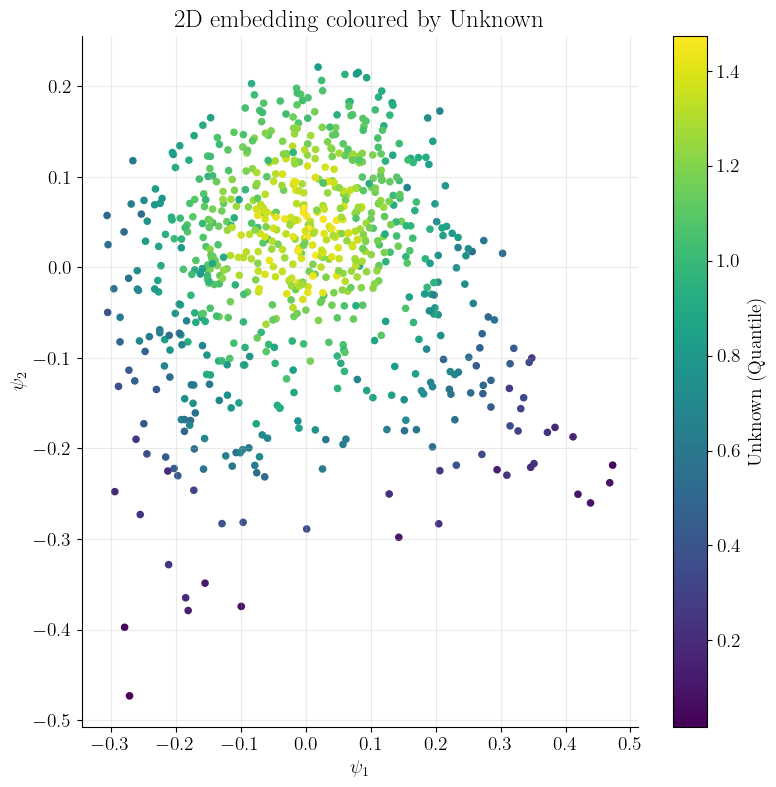

In [20]:
h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi, multiplier=1)

plot_2d(Psi, colour=rho)

### Density ambient distance correlation

In [21]:
A_dist_real = kneighbors_graph(Z, n_neighbors=K_GRAPH, mode="distance", include_self=False)
dk = 1/K_GRAPH * np.asarray(A_dist_real.sum(axis=1)).squeeze()

# Non-linear distance correlation
d_corr = dcor.distance_correlation(rho, dk)
print(f'Distance correlation: {d_corr:.4f}')

# Standard linear correlations
p_corr, _ = pearsonr(rho, dk)
s_corr, _ = spearmanr(rho, dk)
print(f'Pearson correlation: {p_corr:.4f}')
print(f'Spearman correlation: {s_corr:.4f}')

Distance correlation: 0.4427
Pearson correlation: -0.4563
Spearman correlation: -0.4145


### Density penalty across time

non-NBER high-potential episodes: 16
      date  potential  idx
2010-05-01   1.614248  551
1991-12-01   1.052840  330
2022-09-01   0.907136  699
1990-01-01   0.860545  307
2002-07-01   0.844784  457
2020-11-01   0.837248  677
1975-10-01   0.794583  136
2003-04-01   0.693634  466
1983-04-01   0.689712  226
1966-08-01   0.683519   26
1969-06-01   0.675105   60
2019-05-01   0.643272  659
1986-02-01   0.633806  260
2026-03-01   0.618438  741
1978-10-01   0.589896  172
2011-08-01   0.564666  566


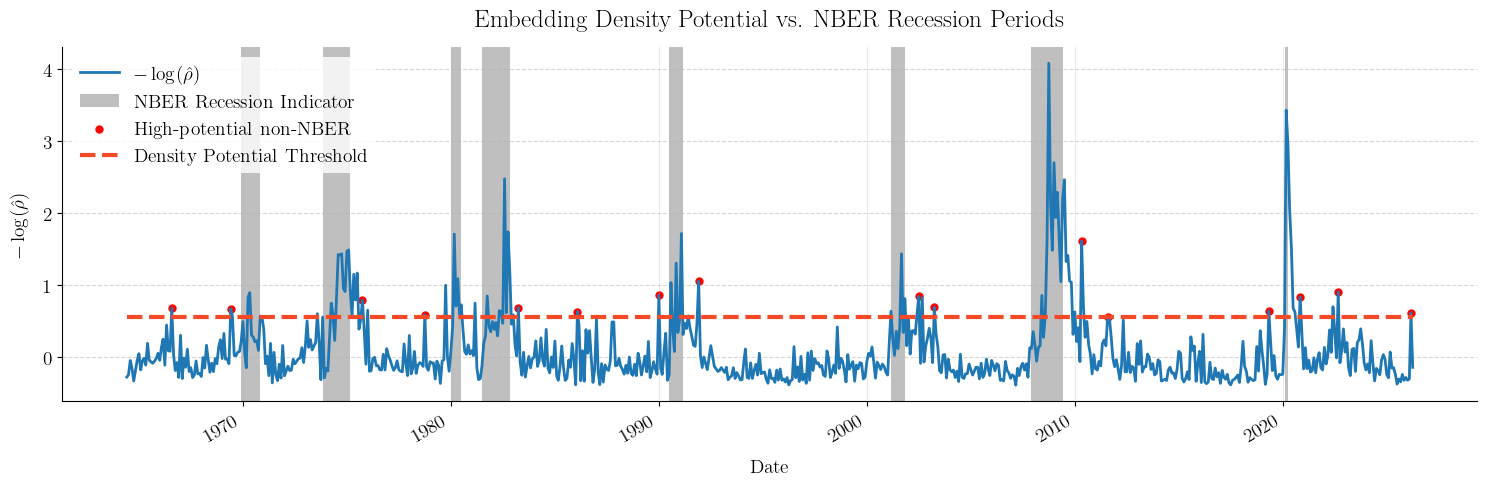

In [22]:
recession_mask = df["recession"].values.astype(bool)
potential_threshold = np.median(V[recession_mask])
pad=4
recession_padded = (pd.Series(recession_mask,index=dates).rolling(2*pad+1,center=True,min_periods=1).max().astype(bool).to_numpy())
series = np.where(~recession_padded,V,-np.inf)
peak_idx,_ = find_peaks(series,height=potential_threshold,distance=9,prominence=0.05)
low_density_episodes = pd.DataFrame({"date":dates[peak_idx],"potential":V[peak_idx],"idx":peak_idx}).sort_values("potential",ascending=False)

print("non-NBER high-potential episodes:", len(low_density_episodes))
print(low_density_episodes.to_string(index=False))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, V, label=r"$-\log(\hat\rho)$", color="#1f77b4", linewidth=2)

y_min, y_max = ax.get_ylim()
ax.fill_between(df.index, y_min, y_max, where=(df["recession"].values == 1), color="gray",
                alpha=0.5, label="NBER Recession Indicator", edgecolor="none")

low_density_indices = low_density_episodes["idx"]
ax.scatter(df.index[low_density_indices], V[low_density_indices], label="High-potential non-NBER", c="r")

ax.hlines(potential_threshold, xmin=df.index[0], xmax=df.index[-1], linestyles="--", label="Density Potential Threshold", colors="#F54927")

ax.set_ylim(y_min, y_max)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.set_title("Embedding Density Potential vs. NBER Recession Periods", fontweight="bold", pad=15)
ax.set_xlabel("Date", labelpad=10); ax.set_ylabel(r"$-\log(\hat\rho)$",labelpad=10)

ax.grid(axis="y", linestyle="--", alpha=0.5); ax.spines[["top", "right"]].set_visible(False) 
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
# plt.savefig("figures/density_penalty_vs_time.pdf")
plt.show()

# 6.3 Stress-path results
### 2D graph path plots

In [23]:
path_records = []
leave_one_out = True

for event, (start_idx, end_idx) in pairs.items():
    idx_graph = graph_path(A_dist_sym, beta=0.0, V=V, start=start_idx, end=end_idx)
    idx_aware = graph_path(A_dist_sym, beta=BETA, V=V, start=start_idx, end=end_idx)

    if leave_one_out:
        density_graph, _ = loo_graph_density(idx_graph, Psi, h_dens, scale)
        density_aware, _ = loo_graph_density(idx_aware, Psi, h_dens, scale)
    else:
        density_graph = rho[idx_graph]
        density_aware = rho[idx_aware]

    n_grid = (len(idx_graph) + len(idx_aware)) // 2
    gamma = linear_path(Psi, start_idx, end_idx, n_grid=n_grid)
    rho_lin, V_lin = latent_density_at_points(gamma, Psi, h_dens, scale)
    Z_lin = local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=M_LIFT, tau=med_Dsq)

    path_records.append({"event": event,"path_type": "density_aware", "coords": Psi[idx_aware],
                         "density": density_aware, "V": V[idx_aware], "Z_lift": Z[idx_aware], "node_indices": idx_aware})
    path_records.append({"event": event, "path_type": "ordinary_graph", "coords": Psi[idx_graph],
                         "density": density_graph, "V": V[idx_graph],"Z_lift": Z[idx_graph], "node_indices": idx_graph})
    path_records.append({"event": event, "path_type": "linear", "coords": gamma, "density": rho_lin, "V": V_lin, "Z_lift": Z_lin})


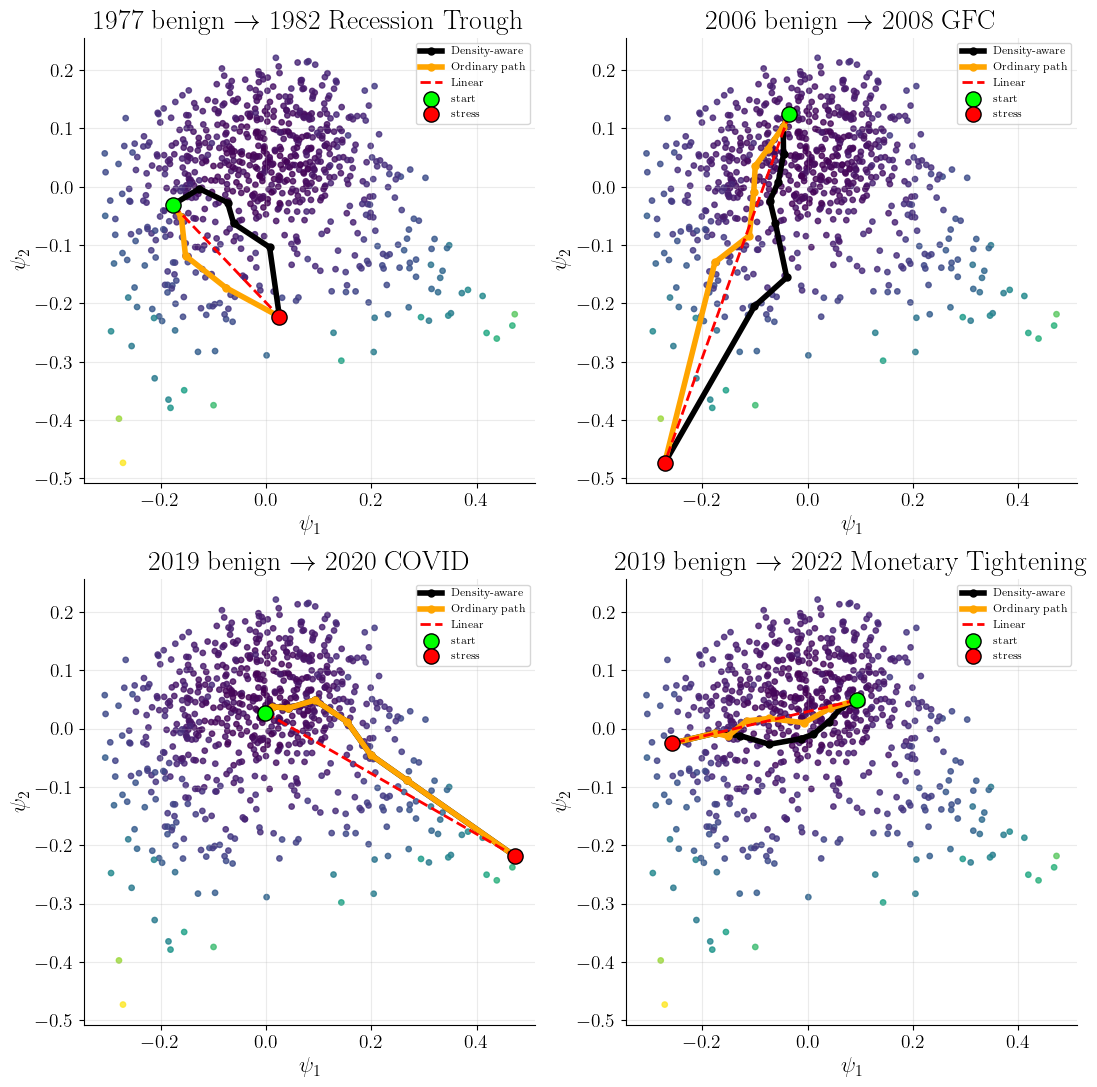

In [24]:
fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_SQ)
axes_flat = axes.flatten()

for ax, event in zip(axes_flat, pairs.keys()):
    event_records = [rec for rec in path_records if rec["event"] == event]
    
    ax.scatter(Psi[:,0], Psi[:,1], c=V, s=15, cmap="viridis", alpha=0.8)

    for rec in event_records:
        coords = rec["coords"]
        p_type = rec["path_type"]
        
        if p_type == "ordinary_graph":
            ax.plot(coords[:, 0], coords[:, 1], marker="o", ms=5, label="Ordinary path", lw=4, c=ORDINARY_COLOUR)
            
        elif p_type == "density_aware":
            ax.plot(coords[:, 0], coords[:, 1], marker="o", ms=5, label="Density-aware", lw=4, c=DENSITY_COLOUR)
            
        elif p_type == "linear":
            ax.plot(coords[:, 0], coords[:, 1], "--", lw=2, label="Linear", c=LINEAR_COLOUR)

    
    ax.scatter(*coords[0,:2], c="lime", s=120, ec="k", zorder=5, label="start")
    ax.scatter(*coords[-1,:2], c="red", s=120, ec="k", zorder=5, label="stress")

    # ax.plot(Psi[s:e+1, 0], Psi[s:e+1, 1], label="real path")

    ax.set_title(event.replace("->", r"$\rightarrow$"), fontsize=20)
    ax.set_xlabel(r"$\psi_1$", fontsize=16)
    ax.set_ylabel(r"$\psi_2$", fontsize=16)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("./figures/all_paths_on_embedding_2d.pdf")
plt.show()

### Density along paths

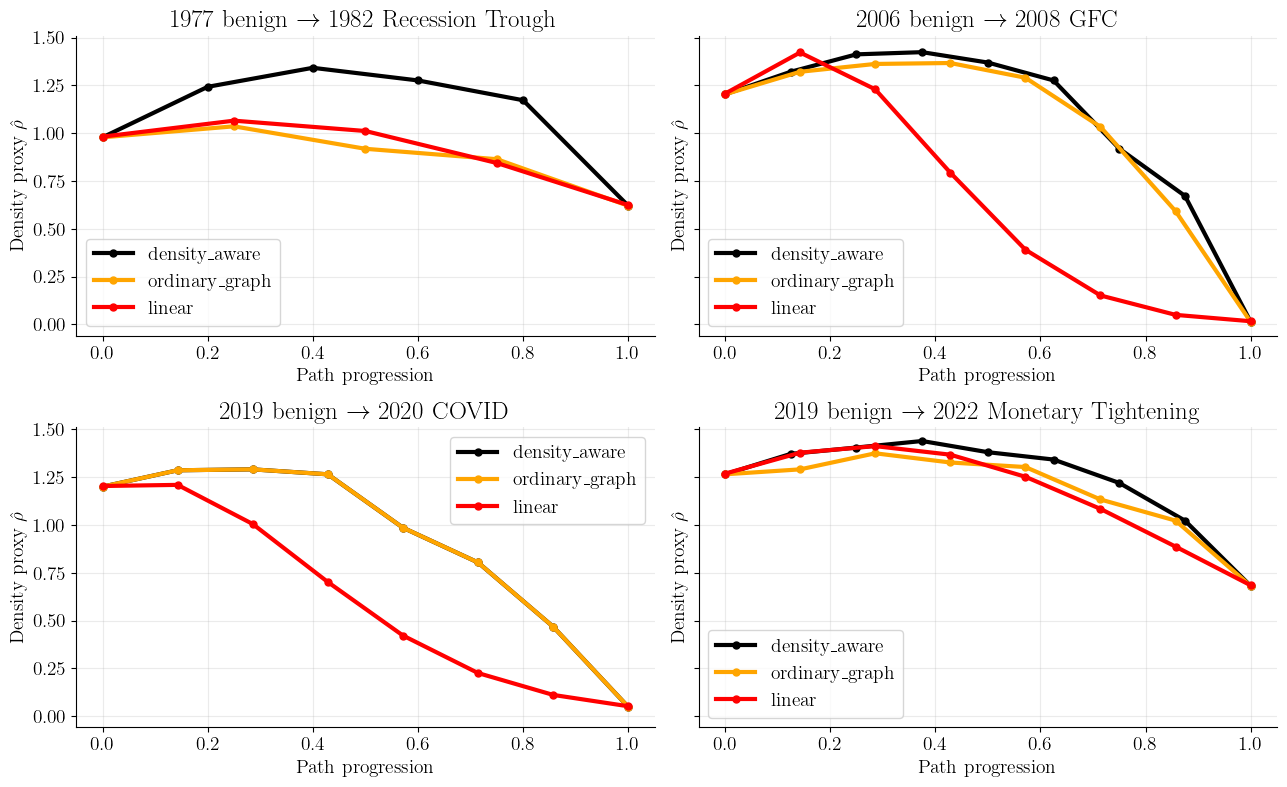

In [25]:
events = list(pairs.keys())

fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD, sharey=True)

for ax, event in zip(axes.flatten(), events):
    event_records = [rec for rec in path_records if rec["event"] == event and rec["path_type"] != "observed"]

    for rec in event_records:
        density = rec["density"]
        x = np.linspace(0, 1, len(density))
        c = colour_map.get(rec["path_type"], None)
        ax.plot(x, density, marker="o", label=rec["path_type"], c=c)

    ax.set_title(event.replace("->", r"$\rightarrow$")); ax.set_xlabel("Path progression")
    ax.set_ylabel(r"Density proxy $\hat{\rho}$")
    ax.legend()

plt.tight_layout()
plt.savefig("./figures/density_along_paths_all_events.pdf") #.png", dpi=300, bbox_inches='tight')
plt.show()

### Main results table

In [26]:
def total_turning_angle(coords):
    d = np.diff(coords, axis=0)
    u = d / np.linalg.norm(d, axis=1)[:, None]
    dot_products = np.sum(u[:-1] * u[1:], axis=1)
    theta = np.arccos(np.clip(dot_products, -1.0, 1.0))
    return np.sum(theta)

def weighted_mean_density(coords, density):
    lengths = np.linalg.norm(np.diff(coords, axis=0), axis=1)
    return np.sum((density[1:] + density[:-1]) * lengths) / (2 * np.sum(lengths))

def latent_path_length(coords):
    diffs = np.diff(coords, axis=0)
    return np.linalg.norm(diffs, axis=1).sum()

In [27]:
rows = []

for rec in path_records:
    coords = rec["coords"]; density = rec["density"]
    density_int = interior_values(density)

    rows.append({
        "event": rec["event"],
        "path_type": rec["path_type"],
        "interior_minimum_density": density_int.min(),
        "weighted_mean_density": weighted_mean_density(coords, density),
        "latent_path_length": latent_path_length(coords),
        "total_turning_angle": total_turning_angle(coords),
    })

metrics_df = pd.DataFrame(rows)

In [28]:
for event in metrics_df["event"].unique():
    event_table = (metrics_df[metrics_df["event"] == event].set_index("path_type").drop(columns="event"))
    print(event)
    display(event_table.round(4))

1977 benign -> 1982 Recession Trough


,interior_minimum_density,weighted_mean_density,latent_path_length,total_turning_angle
path_type,,,,
density_aware,1.1726,1.1203,0.4019,3.8106
ordinary_graph,0.8643,0.8660,0.3502,2.4487
linear,0.8444,0.9312,0.2949,0.0000


2006 benign -> 2008 GFC


,interior_minimum_density,weighted_mean_density,latent_path_length,total_turning_angle
path_type,,,,
density_aware,0.6723,0.7623,0.8575,4.9936
ordinary_graph,0.5923,0.7246,0.8390,4.0341
linear,0.0502,0.6644,0.7777,0.0000


2019 benign -> 2020 COVID


,interior_minimum_density,weighted_mean_density,latent_path_length,total_turning_angle
path_type,,,,
density_aware,0.4682,0.7034,0.6947,3.72
ordinary_graph,0.4682,0.7034,0.6947,3.72
linear,0.1114,0.6149,0.6368,0.00


2019 benign -> 2022 Monetary Tightening


,interior_minimum_density,weighted_mean_density,latent_path_length,total_turning_angle
path_type,,,,
density_aware,1.0228,1.2320,0.4631,4.9583
ordinary_graph,1.0228,1.1872,0.4484,5.9633
linear,0.8868,1.1940,0.3719,0.0000


# 6.4 Lifted-path results

In [29]:
def lift_operator(Z, Psi):
    Z_mean, Psi_mean = Z.mean(0), Psi.mean(0)
    H = np.linalg.lstsq(Psi - Psi_mean, Z - Z_mean, rcond=None)[0].T
    Z_hat = (Psi - Psi_mean) @ H.T + Z_mean
    RMSE = np.sqrt(np.mean(np.sum((Z - Z_hat)**2, axis=1)))
    return H, RMSE, Z_mean, Psi_mean

def baker_error(Z, Psi):
    Z_hat = np.zeros_like(Z, dtype=float)
    for i in range(len(Z)):
        mask = np.arange(len(Z)) != i
        H, _, Z_mean, Psi_mean = lift_operator(Z[mask], Psi[mask])
        Z_hat[i] = H @ (Psi[i] - Psi_mean) + Z_mean
    RMSE = np.sqrt(np.mean(np.sum((Z - Z_hat)**2, axis=1)))
    return Z_hat, RMSE

def mean_baseline_error(Z):
    Z_hat = np.zeros_like(Z, dtype=float)
    for i in range(len(Z)):
        mask = np.arange(len(Z)) != i
        Z_hat[i] = Z[mask].mean(axis=0)
    RMSE = np.sqrt(np.mean(np.sum((Z - Z_hat)**2, axis=1)))
    return Z_hat, RMSE

### Min RMSE value over $m$

[]

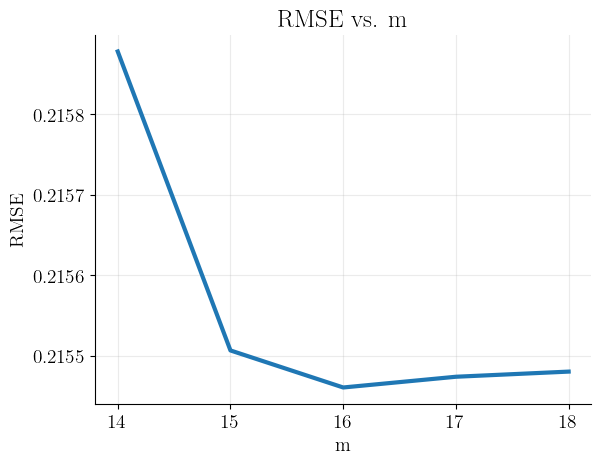

In [30]:
rmses = []
ms = [14, 15, 16, 17, 18]
for m in ms:
    RMSE = lnl_error(Psi, Z, m=m, tau=med_Dsq)["lift_RMSE"]
    rmses.append(RMSE)
    
plt.plot(ms, rmses)
plt.title("RMSE vs. m")
plt.xlabel("m"); plt.ylabel("RMSE")
plt.plot()

### RMSE and $R^2$ for LNL and Baker-style lifting methods

### Ambient diagnostics

In [ ]:
def baker_lift(Z, Psi, start_idx, end_idx, n_grid=40):
    H, _, Z_mean, Psi_mean = lift_operator(Z, Psi)
    gamma = np.linspace(Psi[start_idx], Psi[end_idx], num=n_grid)
    z_hat = (gamma - Psi_mean) @ H.T + Z_mean
    z_hat[0] = Z[start_idx]; z_hat[-1] = Z[end_idx]
    return z_hat, gamma

def lift_validation(z_hat, Z):
    nn = NearestNeighbors(n_neighbors=1); nn.fit(Z)
    dNN, _ = nn.kneighbors(z_hat)
    return dNN

h, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

idx_pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

lifted_paths = {name: {"LNL": None, "baker": None, "lnl_validation": None, "baker_validation": None, "density": None} for name in idx_pairs.keys()}

for event, (start_idx, end_idx) in idx_pairs.items():
    gamma = linear_path(Psi, start_idx, end_idx, n_grid=10)
    z_lnl = local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=17, tau=med_Dsq)
    z_baker, _ = baker_lift(Z, Psi, start_idx, end_idx)
    lifted_paths[event]["LNL"] = z_lnl
    lifted_paths[event]["baker"] = z_baker
    lifted_paths[event]["lnl_validation"] = lift_validation(z_lnl, Z)
    lifted_paths[event]["baker_validation"] = lift_validation(z_baker, Z)
    lifted_paths[event]["density"] = latent_density_at_points(gamma, Psi, h, scale)[0]

In [41]:
DZ = squareform(pdist(Z))
np.fill_diagonal(DZ, np.inf)

d_Z = np.min(DZ, axis=1)

d_Z_median = np.median(d_Z)
d_Z_95 = np.quantile(d_Z, 0.95)

rows = []

for event in lifted_paths.keys():
    d_lnl = np.ravel(lifted_paths[event]["lnl_validation"])[1:-1]
    d_baker = np.ravel(lifted_paths[event]["baker_validation"])[1:-1]

    rows.append({"event": event, "path_type": "LNL", "median_dNN": np.median(d_lnl), "quantile_ratio": np.quantile(d_lnl, 0.95) / d_Z_95})
    rows.append({"event": event, "path_type": "Baker", "median_dNN": np.median(d_baker), "quantile_ratio": np.quantile(d_baker, 0.95) / d_Z_95})

plausibility_df = pd.DataFrame(rows)
display(plausibility_df)

,event,path_type,median_dNN,quantile_ratio
0,1977 benign -> 1982 Recession Trough,LNL,1.071424,0.691027
1,1977 benign -> 1982 Recession Trough,Baker,1.040180,0.659021
2,2006 benign -> 2008 GFC,LNL,1.046118,0.702600
3,2006 benign -> 2008 GFC,Baker,1.145838,1.064991
4,2019 benign -> 2020 COVID,LNL,1.003461,0.643572
5,2019 benign -> 2020 COVID,Baker,1.087547,0.887815
6,2019 benign -> 2022 Monetary Tightening,LNL,1.072579,0.657930
7,2019 benign -> 2022 Monetary Tightening,Baker,1.099502,0.679118


### Plotting lifted paths

In [42]:
R_PCA = 4
pca = PCA(n_components=R_PCA); Psi_pca = pca.fit_transform(Z)
PCA_dist = kneighbors_graph(Psi_pca, n_neighbors=K_GRAPH, mode="distance", include_self=False)
PCA_dist_sym = A_dist.maximum(PCA_dist.T)
# Load the quantile inverse
qt = joblib.load("models/quantile_transformer.joblib")

In [43]:
lifted_path_records = []

for event, (start_idx, end_idx) in pairs.items():
    # Graph path
    idx_graph = graph_path(A_dist_sym, beta=0.0, V=V, start=start_idx, end=end_idx)
    idx_aware = graph_path(A_dist_sym, beta=BETA, V=V, start=start_idx, end=end_idx)

    # PCA path
    n_grid = (len(idx_graph) + len(idx_aware)) // 2
    alpha = np.linspace(0, 1, n_grid)[:, None]
    gamma_pca = ((1 - alpha) * Psi_pca[start_idx] + alpha * Psi_pca[end_idx])
    Z_pca_quantile = pca.inverse_transform(gamma_pca)
    Z_pca_quantile[0] = Z[start_idx]; Z_pca_quantile[-1] = Z[end_idx]     # Can choose to fix PCA endpoints
    Z_pca_real = qt.inverse_transform(Z_pca_quantile)
    pca_lift_val = lift_validation(Z_pca_quantile, Z)
    start_error = Z_pca_quantile[0] - Z[start_idx]; end_error   = Z_pca_quantile[-1] - Z[end_idx]
    start_error_norm = np.linalg.norm(start_error); end_error_norm   = np.linalg.norm(end_error)

    # Linear lift using LNL
    gamma = linear_path(Psi, start_idx, end_idx, n_grid)
    rho_lin, V_lin = latent_density_at_points(gamma, Psi, h_dens, scale)
    Z_lin_quantile = local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=M_LIFT, tau=med_Dsq)
    Z_lin_real = local_neighbourhood_lifting(Z_real, Psi, gamma, start_idx, end_idx, m=M_LIFT, tau=med_Dsq)
    Z_lin_real_q = qt.inverse_transform(Z_lin_quantile)
    lnl_lift_val = lift_validation(Z_lin_quantile, Z)

    # Observed path
    quantile_path = Z[start_idx:end_idx+1]
    real_path = Z_real[start_idx:end_idx+1]

    lifted_path_records.append({"event": event, "path_type": "linear", "Z_lift_quantile": Z_lin_quantile, "Z_lift_real": Z_lin_real, "Z_lift_real_inverse": Z_lin_real_q, "dNN": lnl_lift_val})
    lifted_path_records.append({"event": event, "path_type": "PCA", "Z_lift_quantile": Z_pca_quantile, "Z_lift_real": Z_pca_real, "dNN": pca_lift_val})
    lifted_path_records.append({"event": event, "path_type": "ordinary_graph", "Z_lift_quantile": Z[idx_graph], "Z_lift_real": Z_real[idx_graph], "dNN": None})
    lifted_path_records.append({"event": event, "path_type": "density_aware", "Z_lift_quantile": Z[idx_aware], "Z_lift_real": Z_real[idx_aware], "dNN": None})
    lifted_path_records.append({"event": event, "path_type": "observed", "Z_lift_quantile": quantile_path, "Z_lift_real": real_path, "dNN": None})

In [44]:
event_variables = {
    "1977 benign -> 1982 Recession Trough": ["FEDFUNDS", "UNRATE"],
    "2006 benign -> 2008 GFC": ["HOUST", "BAAFFM"],
    "2019 benign -> 2020 COVID": ["CLAIMSx", "VIXCLSx"],
    "2019 benign -> 2022 Monetary Tightening": ["CPIAUCSL", "FEDFUNDS"],
}

transformed_variable_ylabels = {
    "UNRATE": "Unemployment rate (\\%)",
    "HOUST": "Log housing starts",
    "S&P 500": "Monthly log change in S\\&P 500",
    "FEDFUNDS": "Monthly change in federal funds rate",
    "CPIAUCSL": "Second log difference of CPI",
}

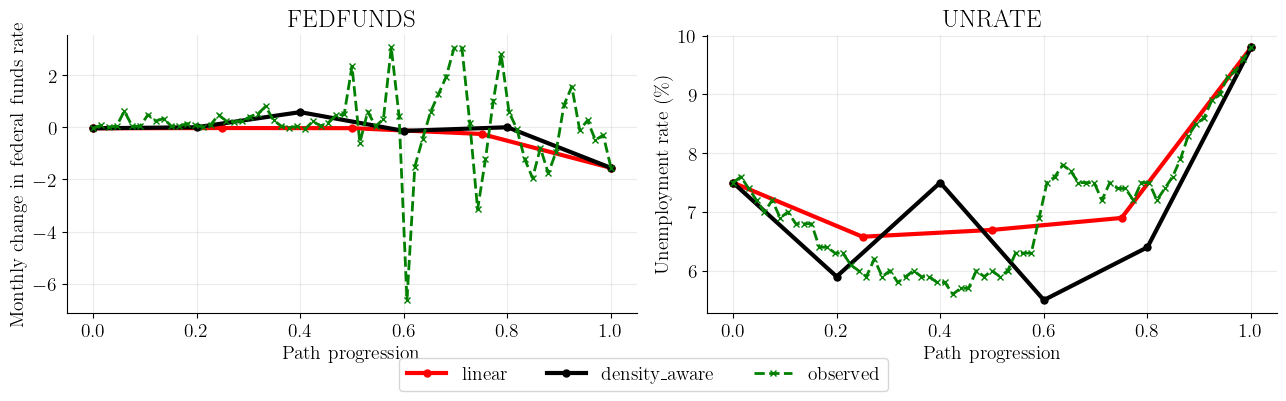

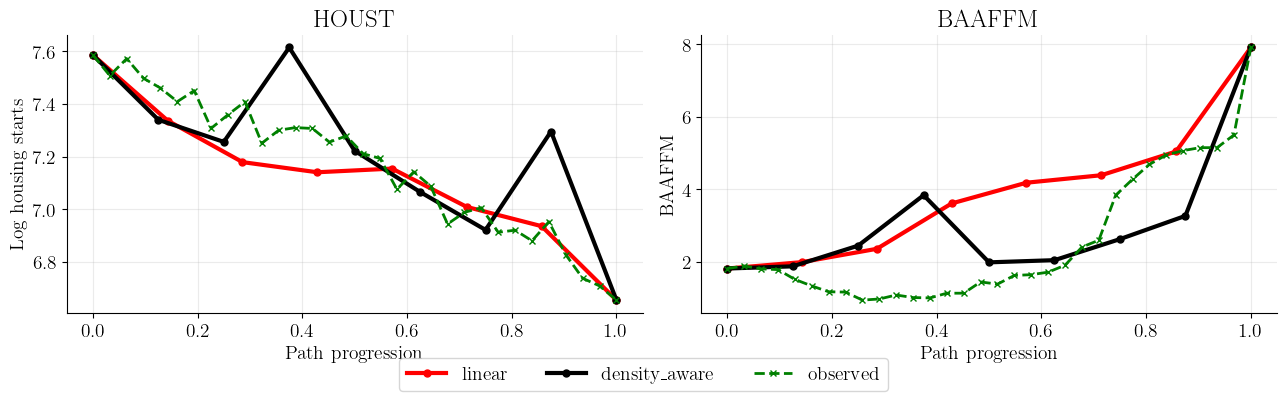

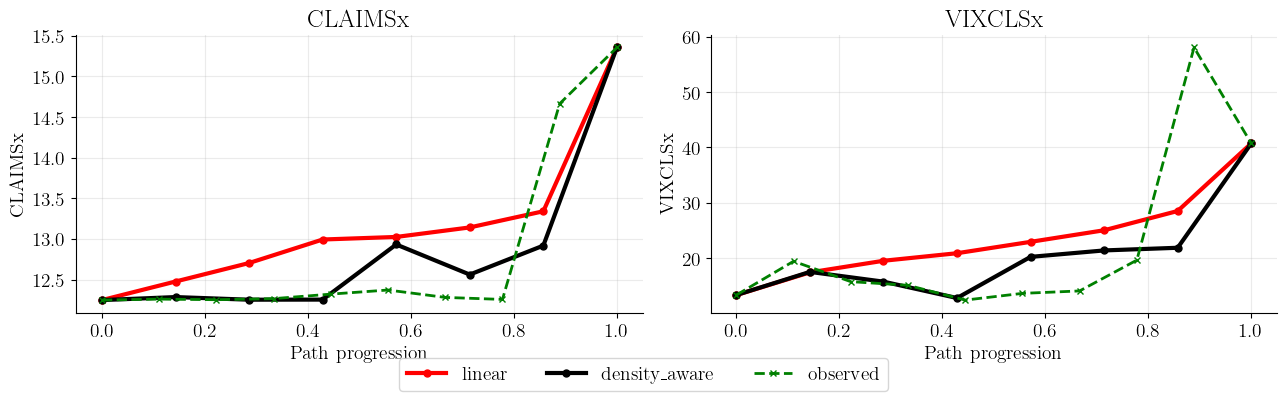

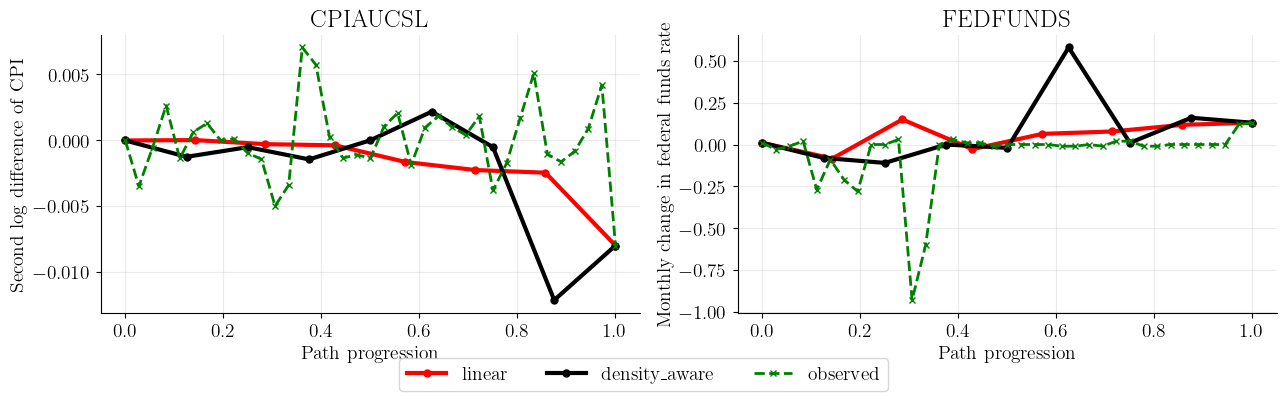

In [45]:
for event, selected_vars in event_variables.items():
    event_records = [rec for rec in lifted_path_records if rec["event"] == event]

    selected_idxs = [variables.get_loc(v) for v in selected_vars]
    n_vars = len(selected_vars); n_rows = 1
    n_cols = int(np.ceil(n_vars / n_rows))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=ps.FIG_DOUBLE_WD, squeeze=False)
    axes_flat = axes.flatten()

    for path in event_records:
        path_type = path["path_type"]
        if path_type not in ["linear", "density_aware", "observed"]:
            continue

        lifted_path = path["Z_lift_real"]
        x = np.linspace(0, 1, len(lifted_path))

        for i, var_idx in enumerate(selected_idxs):
            ax = axes_flat[i]
            c = colour_map[path_type]
            if path_type == "observed":
                ax.plot(x, lifted_path[:, var_idx], marker="x", linestyle="--", label=path_type, lw=2, c=c)
            else:
                ax.plot(x, lifted_path[:, var_idx], marker="o", label=path_type.replace(r"$\\beta=1.5$", ""), c=c)

            ax.set_title(selected_vars[i].replace("&", "\\&"), fontweight='bold')
            ax.set_xlabel("Path progression")
            ax.set_ylabel(transformed_variable_ylabels.get(selected_vars[i], selected_vars[i]))

    for j in range(n_vars, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))

    # event_rename = event.replace("->", r"$\\rightarrow$")
    # plt.suptitle(rf'Selected lifted macro variables: {event_rename}', fontsize=14, fontweight="bold")

    plt.tight_layout(); plt.subplots_adjust(bottom=0.20)
    event_label = event.split(" ")[-1]
    plt.savefig(f"./figures/lifted_macro_vars_{event_label}.pdf")
    plt.show()

### Lifted graph paths vs PCA

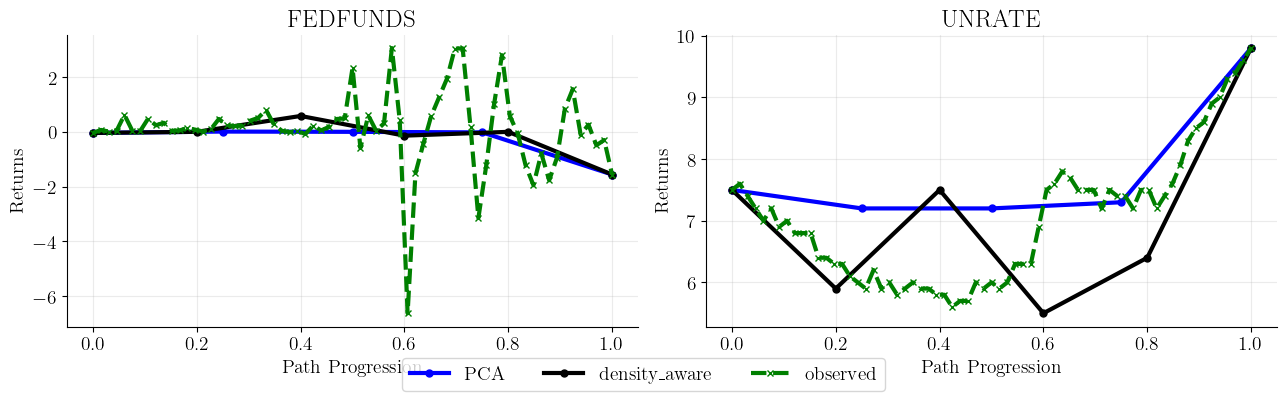

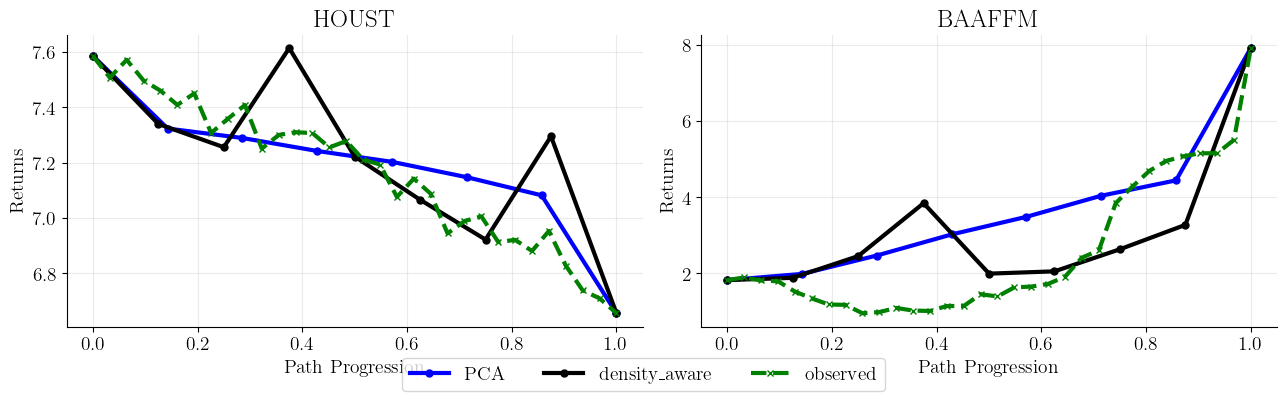

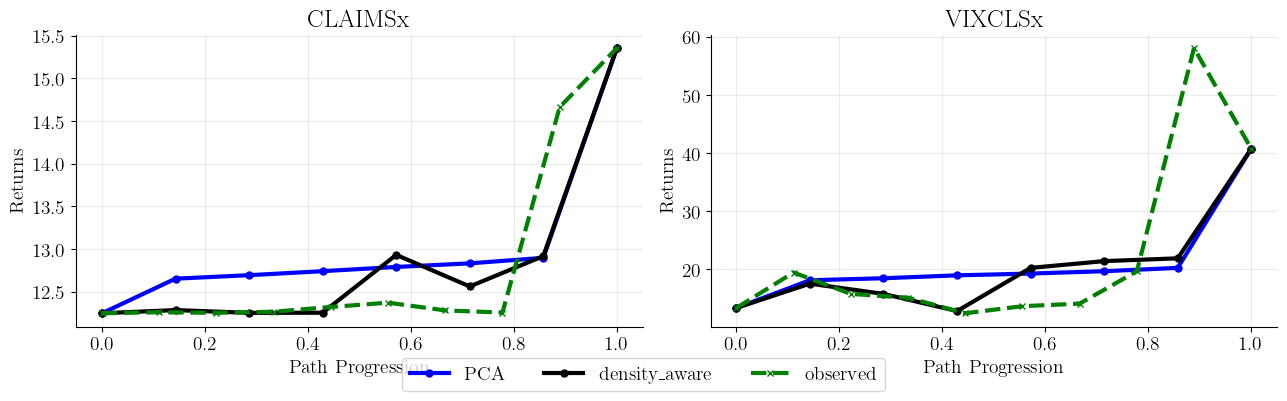

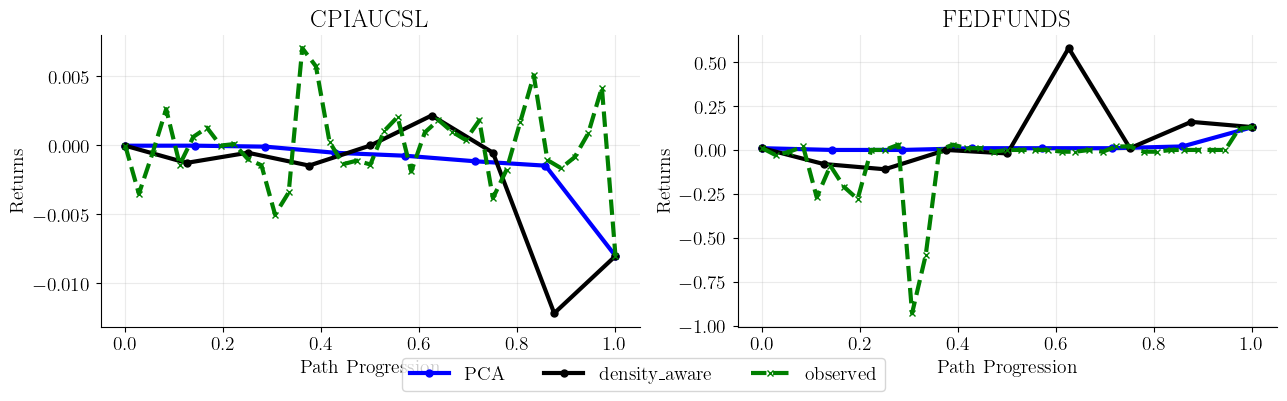

In [46]:
for event, selected_vars in event_variables.items():
    event_records = [rec for rec in lifted_path_records if rec["event"] == event]
    selected_idxs = [variables.get_loc(v) for v in selected_vars]

    n_vars = len(selected_vars); n_cols = 2
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=ps.FIG_DOUBLE_WD, squeeze=False)
    axes_flat = axes.flatten()

    for path in event_records:
        path_type = path["path_type"]
        lifted_path = path["Z_lift_real"]
        x = np.linspace(0, 1, len(lifted_path))

        for i, var_idx in enumerate(selected_idxs):
            ax = axes_flat[i]
            c = colour_map[path_type]
            if path_type == "observed":
                ax.plot(x, lifted_path[:, var_idx], marker="x", linestyle="--", label=path_type, c=c)
            elif path_type == "PCA" or path_type == "density_aware":
                ax.plot(x, lifted_path[:, var_idx], marker="o", label=path_type, c=c)

            ax.set_title(selected_vars[i].replace("&", "\\&"), fontweight='bold')
            ax.set_ylabel("Returns"); ax.set_xlabel("Path Progression")

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))

    event_rename = event.replace("->", r"$\\rightarrow$")
    # plt.suptitle(rf'Lifted macro variable for ({event_rename})', fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"./figures/pca_comparison_{event.split(' ')[-1]}.pdf")
    plt.show()

# 6.5 Robustness of parameters
### Metrics vs. $\beta$

In [47]:
metrics = ['interior_minimum_density', 'weighted_mean_density', 'latent_path_length', 'total_turning_angle']
delta_metrics = ["delta_interior_minimum_density", "delta_weighted_mean_density", "delta_latent_path_length", "delta_total_turning_angle"]

metric_names_clean = {
    "interior_minimum_density": r"Minimum Interior Density ($\rho$)",
    "weighted_mean_density": "Weighted mean density",
    "latent_path_length": "Latent Path Length",
    "total_turning_angle": "Total Turning Angle"
}

delta_metric_names_clean = {
    "delta_interior_minimum_density": r"$\Delta M_\mathrm{min}$",
    "delta_weighted_mean_density": r"$\Delta M_\mathrm{mean}$",
    "delta_latent_path_length": r"$\Delta L_\mathrm{diff}$",
    "delta_total_turning_angle": r"$\Delta \theta_\mathrm{total}$"
}


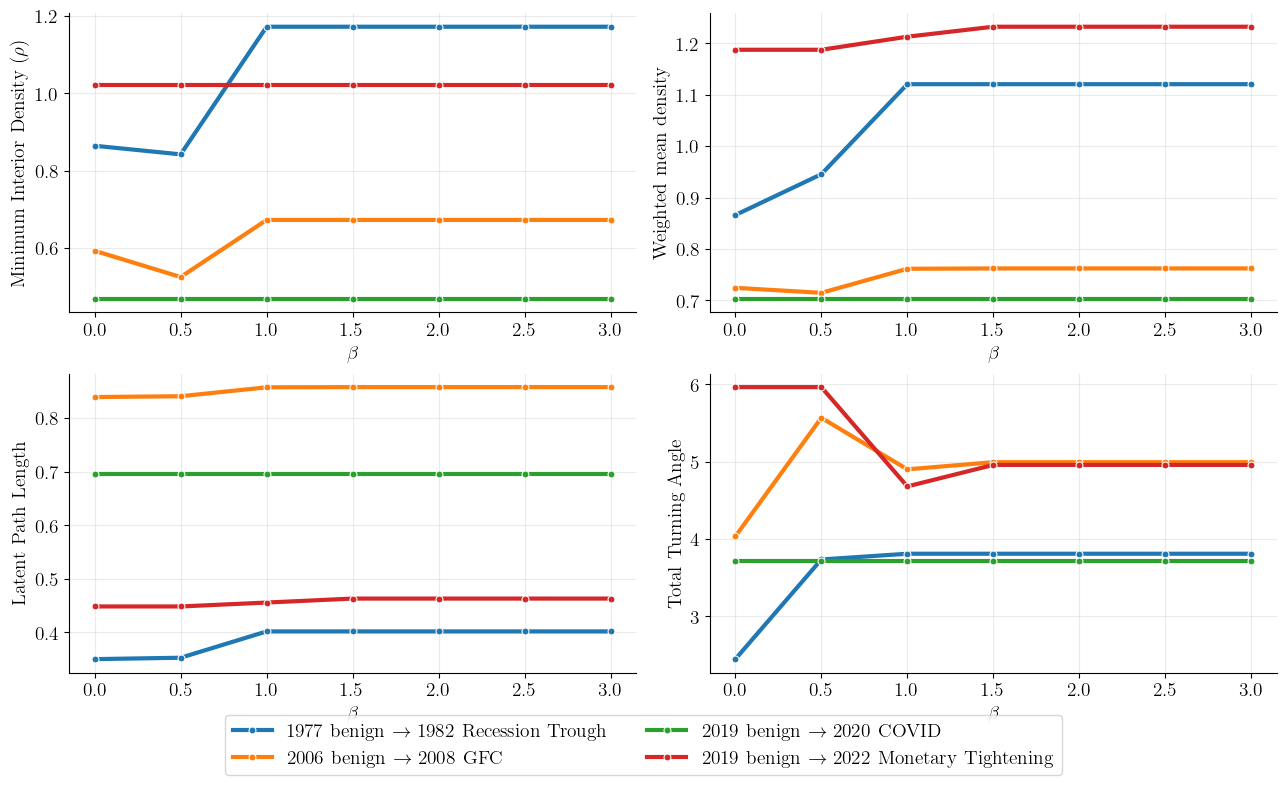

In [48]:
leave_one_out = True

beta_records = []
betas = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

for event, (start_idx, end_idx) in pairs.items():
    for beta in betas:
        idx_graph = graph_path(A_dist_sym, beta=beta, V=V, start=start_idx, end=end_idx)
        P = Psi[idx_graph]
        if leave_one_out: graph_density, _ = loo_graph_density(idx_graph, Psi, h_dens, scale)
        else: graph_density = rho[idx_graph]
        interior_density = interior_values(graph_density)
        beta_records.append({"event": event, "beta": beta, "interior_minimum_density": interior_density.min(), "weighted_mean_density": weighted_mean_density(P, graph_density),
                             "latent_path_length": latent_path_length(P), "total_turning_angle": total_turning_angle(P)})

beta_df = pd.DataFrame(beta_records)

beta_df["event_label"] = beta_df["event"].str.replace("->", r"$\rightarrow$")

fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD)
axes_flat = axes.flatten()

# fig.suptitle(r"Latent path metrics against a changing density penalty $\beta$")

for i, metric in enumerate(metrics):
    sns.lineplot(data=beta_df, x='beta', y=metric, hue='event_label', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(metric_names_clean.get(metric, metric))
    axes_flat[i].set_xlabel(r"$\beta$")

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig("./figures/beta_vary_metrics.pdf")
plt.show()

### Varying $k$ in graph constsruction

In [49]:
leave_one_out = True

path_settings = {"ordinary graph": 0.0, "density-aware graph": BETA}
rows = []

for name, (s, e) in pairs.items():
    
    ks = [5, 10, 15, 20, 25, 30]
    for k in ks:
        A_dist_k = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
        A_dist_sym_k = A_dist_k.maximum(A_dist_k.T)

        for path_type, beta in path_settings.items():
            p = graph_path(A_dist_sym_k, beta, V, s, e)
            P = Psi[p]; V_path = V[p]
            if leave_one_out: density, _ = loo_graph_density(p, Psi, h_dens, scale)
            else: density = rho[p]
            interior_density = interior_values(density)

            rows.append({"k": k, "path_type": path_type, "event": name, "interior_minimum_density": interior_density.min(), "weighted_mean_density": weighted_mean_density(P, density), "latent_path_length": latent_path_length(P), "total_turning_angle": total_turning_angle(P)})

knn_res = pd.DataFrame(rows)

In [50]:
knn_res["event_label"] = knn_res["event"].str.replace("->", r"$\rightarrow$")

ordinary = (knn_res[knn_res["path_type"] == "ordinary graph"].set_index(["k", "event_label"])[metrics])
aware = (knn_res[knn_res["path_type"] == "density-aware graph"].set_index(["k", "event_label"])[metrics])

df_k_delta = (aware - ordinary).reset_index()
df_k_delta = df_k_delta.rename(columns={m: f"delta_{m}" for m in metrics})

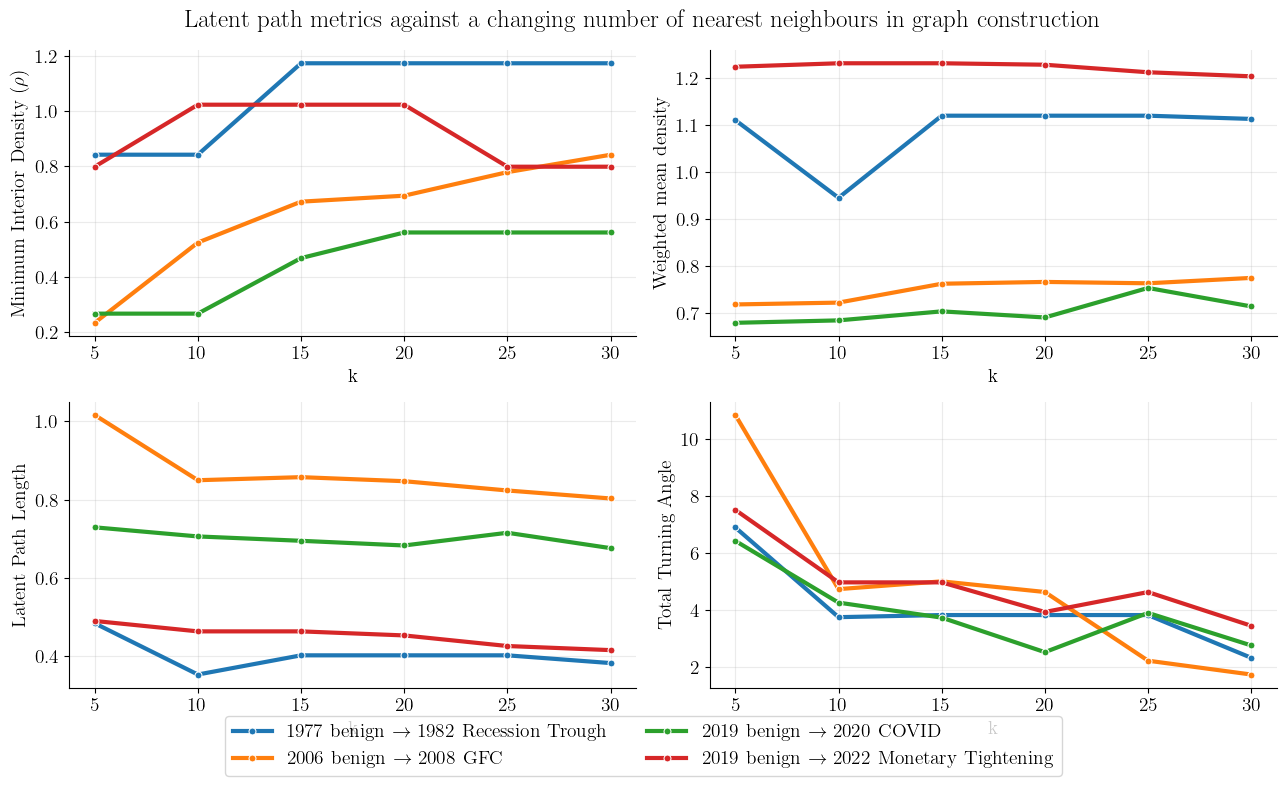

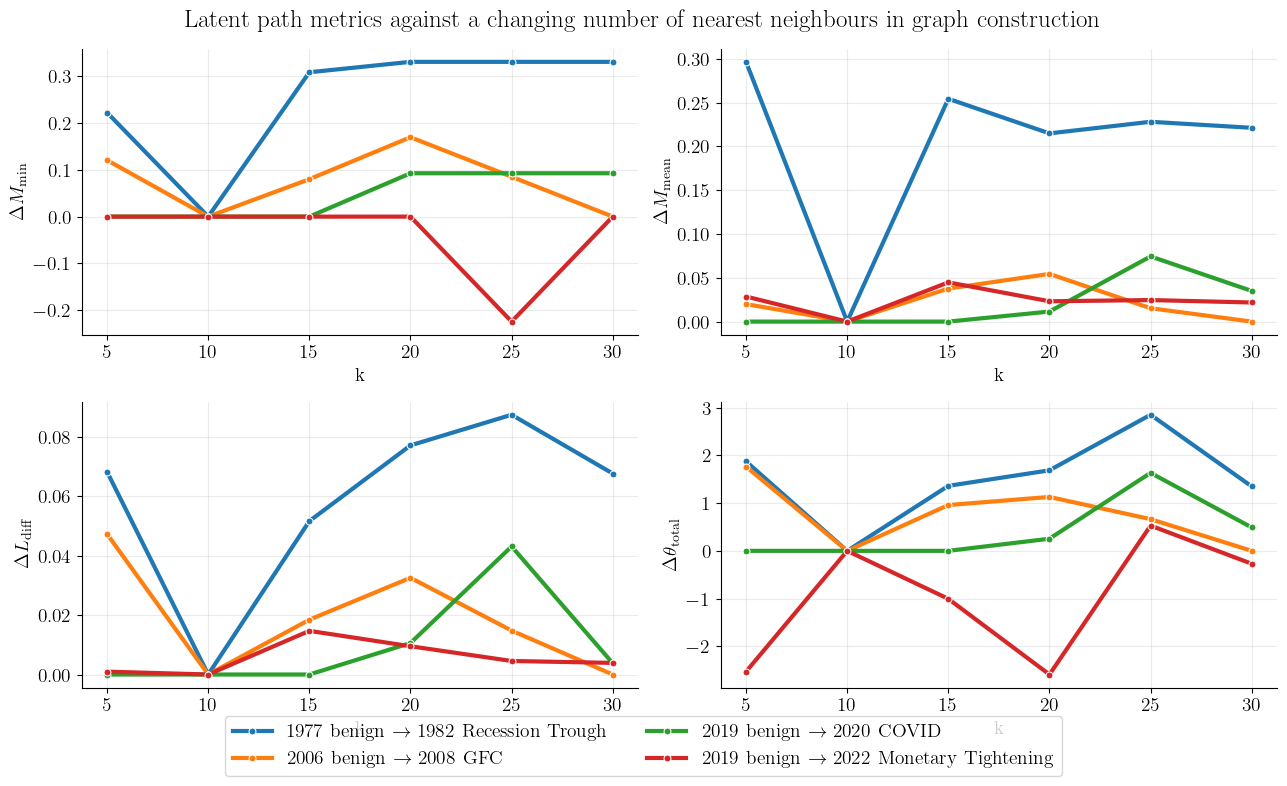

In [51]:
fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD)
axes_flat = axes.flatten()

fig.suptitle("Latent path metrics against a changing number of nearest neighbours in graph construction")


knn_res_aware = knn_res[knn_res["path_type"] == "density-aware graph"]
for i, metric in enumerate(metrics):
    sns.lineplot(data=knn_res_aware, x='k', y=metric, hue='event_label', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(metric_names_clean.get(metric, metric))

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


knn_plot = knn_res[knn_res["path_type"] == "density-aware graph"]

fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD)
axes_flat = axes.flatten()
fig.suptitle("Latent path metrics against a changing number of nearest neighbours in graph construction")
for i, metric in enumerate(delta_metrics):
    sns.lineplot(data=df_k_delta, x='k', y=metric, hue='event_label', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(delta_metric_names_clean.get(metric, metric))

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("./figures/robustness_k.pdf")
plt.show()

### Vary the bandwidth $\varepsilon$

In [52]:
eps_values = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
path_rows = []; embedding_rows = []
path_settings = {"ordinary graph": 0.0, "density-aware graph": BETA}

for eps in eps_values:
    # Recompute diffusion embedding
    diff_eps = diffusion_map(Z, eps=eps, k=N_DIFFUSION_COORDS)
    Psi_eps = diff_eps["Psi"]; evals = diff_eps["evals"]
    h_dens_eps, med_Dsq_eps, density_output = density_and_bandwidth(Psi_eps, multiplier=0.1)
    rho_eps, V_eps, scale_eps = density_output

    # Construct kNN graph
    A_dist_eps = kneighbors_graph(Psi_eps, n_neighbors=K_GRAPH, mode="distance", include_self=False)
    A_dist_sym_eps = A_dist_eps.maximum(A_dist_eps.T)
    n_components = connected_components(A_dist_sym_eps, directed=False, return_labels=False)
    degree = np.asarray((A_dist_sym_eps > 0).sum(axis=1)).ravel()
    edge_lengths = A_dist_sym_eps.data
    median_edge_length = np.median(edge_lengths)
    max_edge_length = np.max(edge_lengths)

    # Compute paths for every event
    for event, (start_idx, end_idx) in pairs.items():
        for path_type, beta in path_settings.items():
            idx_path = graph_path(A_dist_sym_eps, beta=beta, V=V_eps, start=start_idx, end=end_idx)
            coords = Psi_eps[idx_path]; V_path = V_eps[idx_path]

            if leave_one_out: path_density, _ = loo_graph_density(idx_path, Psi_eps, h_dens_eps, scale_eps)
            else: path_density = rho[idx_path]
            interior_density = interior_values(path_density)

            path_length = latent_path_length(coords)
            path_rows.append({"eps": eps, "event": event, "path_type": path_type, "interior_minimum_density": interior_density.min(), "weighted_mean_density": weighted_mean_density(coords, path_density),
                             "latent_path_length": latent_path_length(coords), "total_turning_angle": total_turning_angle(coords)})

In [53]:
eps_path_df = pd.DataFrame(path_rows)
eps_path_df["event_label"] = eps_path_df["event"].str.replace("->", r"$\rightarrow$")

ordinary_eps = (eps_path_df[eps_path_df["path_type"] == "ordinary graph"].set_index(["eps", "event_label"])[metrics])
aware_eps = (eps_path_df[eps_path_df["path_type"] == "density-aware graph"].set_index(["eps", "event_label"])[metrics])

df_eps_delta = (aware_eps - ordinary_eps).reset_index()

df_eps_delta = df_eps_delta.rename(columns={m: f"delta_{m}" for m in metrics})

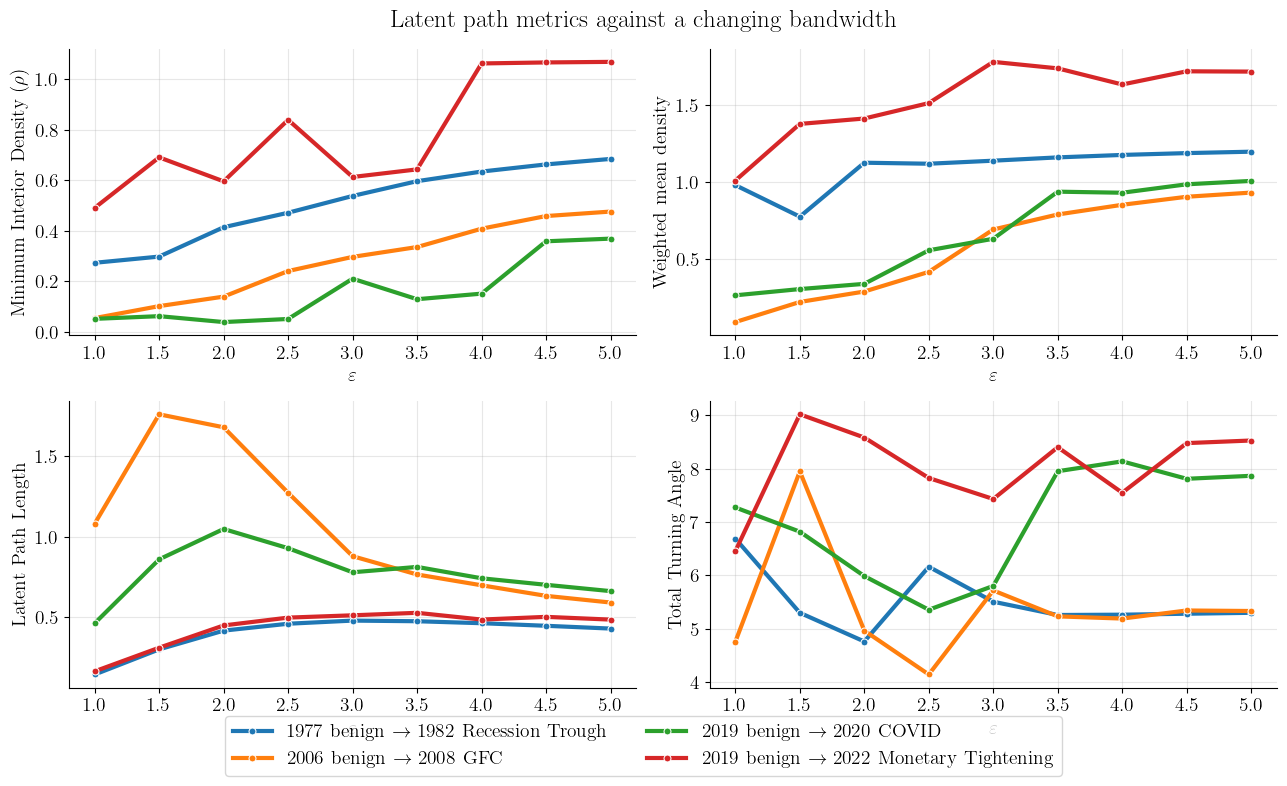

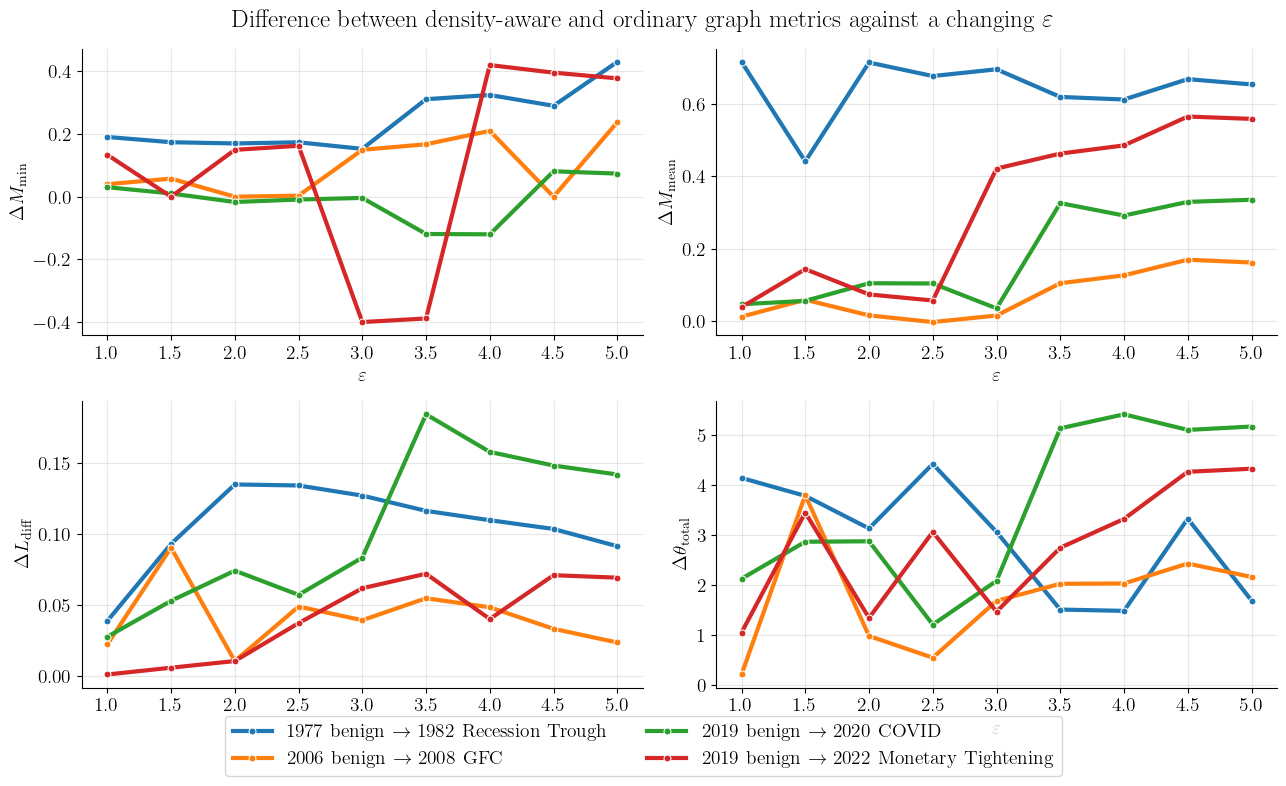

In [54]:
fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD)
axes_flat = axes.flatten()

fig.suptitle("Latent path metrics against a changing bandwidth")

path_df_plot = eps_path_df[eps_path_df["path_type"] != "ordinary graph"]
for i, metric in enumerate(metrics):
    sns.lineplot(data=path_df_plot, x='eps', y=metric, hue='event_label', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(metric_names_clean.get(metric, metric)); axes_flat[i].set_xlabel(r"$\varepsilon$")
    axes_flat[i].grid(alpha=GRID_ALPHA)

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("./figures/robustness_eps.pdf")
plt.show()


fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD); axes_flat = axes.flatten()

fig.suptitle(r"Difference between density-aware and ordinary graph metrics against a changing $\varepsilon$")
for i, metric in enumerate(delta_metrics):
    sns.lineplot(data=df_eps_delta, x='eps', y=metric, hue='event_label', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(delta_metric_names_clean.get(metric, metric)); axes_flat[i].set_xlabel(r"$\varepsilon$")
    axes_flat[i].grid(alpha=GRID_ALPHA)

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("./figures/robustness_k.pdf")
plt.show()

### Density kernel robustness

In [55]:
def compare_densities(rho_graph, rho_kde, sparse_q=0.10):
    rho_graph = np.asarray(rho_graph); rho_kde = np.asarray(rho_kde)
    spearman = spearmanr(rho_graph, rho_kde).statistic
    pearson_log = pearsonr(np.log(rho_graph), np.log(rho_kde)).statistic
    distance_corr = dcor.distance_correlation(np.asarray(rho_graph), np.asarray(rho_kde))

    n_sparse = max(1, int(np.ceil(sparse_q * len(rho_graph))))
    graph_sparse = set(np.argsort(rho_graph)[:n_sparse])
    kde_sparse = set(np.argsort(rho_kde)[:n_sparse])

    sparse_overlap = (len(graph_sparse & kde_sparse) / len(graph_sparse | kde_sparse))

    return {"spearman_density": spearman, "distance_density": distance_corr, "pearson_log_density": pearson_log, "sparse_set_jaccard": sparse_overlap}

In [56]:
def fit_kde_method(Psi, bandwidth, kernel="gaussian", floor=1e-6):
    model = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(Psi)

    raw_node_density = np.exp(model.score_samples(Psi)); scale = raw_node_density.mean()
    rho = np.maximum(raw_node_density / scale, floor); V = -np.log(rho)

    def evaluate(points):
        points = np.atleast_2d(points)
        raw_density = np.exp(model.score_samples(points))
        rho_points = np.maximum(raw_density / scale, floor)
        return rho_points, -np.log(rho_points)

    def loo_evaluate(indices):
        rho_out = np.zeros(len(indices))
        V_out = np.zeros(len(indices))
        for p, idx in enumerate(indices):
            mask = np.ones(len(Psi), dtype=bool); mask[idx] = False
            loo_model = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(Psi[mask])
            raw_density = np.exp(loo_model.score_samples(Psi[idx:idx+1]))[0]
            raw_density *= (len(Psi) -1) / len(Psi)
            rho_out[p] = max(raw_density / scale, floor); V_out[p] = -np.log(rho_out[p])

        return rho_out, V_out
    return {"rho": rho, "V": V, "evaluate": evaluate, "loo_evaluate": loo_evaluate, "model": model, "scale": scale, "bandwidth": bandwidth}


def graph_degree_method(Psi, h, rho, V, scale):
    def evaluate(points):
        rho_points, _ = latent_density_at_points(np.atleast_2d(points), Psi, h, scale)
        return rho_points, -np.log(rho_points)
    def loo_evaluate(indices):
        return loo_graph_density(indices, Psi, h, scale)

    return {"rho": rho, "V": V, "evaluate": evaluate, "loo_evaluate": loo_evaluate, "model": None, "scale": scale, "bandwidth": h}

h_dens, _, (rho_graph_nodes, V_graph_nodes, graph_scale) = density_and_bandwidth(Psi)
kde_bandwidth = np.sqrt(h_dens / 2)

density_methods = {"Gh degree": graph_degree_method(Psi, h_dens, rho_graph_nodes, V_graph_nodes, graph_scale),
                   "Gaussian KDE": fit_kde_method(Psi, kde_bandwidth, kernel="gaussian"),
                   "Epanechnikov": fit_kde_method(Psi, kde_bandwidth, kernel="epanechnikov"),
                   "Exponential": fit_kde_method(Psi, kde_bandwidth, kernel="exponential")}

In [57]:
leave_one_out = True

rows = []
density_paths = {}

for event, (start_idx, end_idx) in pairs.items():
    density_paths[event] = {}

    # Ordinary graph path is also common to every estimator
    idx_ordinary = graph_path(A_dist_sym, beta=0.0, V=V_graph_nodes, start=start_idx, end=end_idx)
    ordinary_nodes = Psi[idx_ordinary]
    ordinary_length = latent_path_length(ordinary_nodes)

    baseline_method_name = "Gh degree"
    baseline_method = density_methods[baseline_method_name]
    idx_baseline = graph_path(A_dist_sym, beta=BETA, V=baseline_method["V"], start=start_idx, end=end_idx)

    n_grid = (len(idx_ordinary) + len(idx_baseline)) // 2
    
    # The same linear path is evaluated under every density estimator
    gamma_linear = linear_path(Psi, start_idx, end_idx, n_grid=n_grid)
    linear_length = np.linalg.norm(Psi[end_idx] - Psi[start_idx])


    for method_name, method in density_methods.items():
        if method_name == "Gaussian KDE":
            continue
        elif method_name == baseline_method_name:
            idx_density = idx_baseline
        else:
            idx_density = graph_path(A_dist_sym, beta=BETA, V=method["V"], start=start_idx, end=end_idx)

        density_paths[event][method_name] = {}

        density_nodes = Psi[idx_density]
        density_length = latent_path_length(density_nodes)

        paths = {"ordinary_graph": {"points": ordinary_nodes, "indices": idx_ordinary, "n_vertices": len(idx_ordinary), "path_length": ordinary_length},
                 "density_aware": {"points": density_nodes, "indices": idx_density, "n_vertices": len(idx_density), "path_length": density_length}, 
                 "linear": {"points": gamma_linear, "indices": None, "n_vertices": n_grid, "path_length": linear_length}}

        for path_type, path in paths.items():

            if leave_one_out:
                if path_type != "linear":
                    rho_path, _ = method["loo_evaluate"](path["indices"])
                    interior_density = interior_values(rho_path)
                else:
                    rho_path, _ = method["evaluate"](path["points"])
                    interior_density = interior_values(rho_path)
            else:
                rho_path, _ = method["evaluate"](path["points"])
                interior_density = interior_values(rho_path)        

            rows.append({"event": event, "density_method": method_name, "path_type": path_type,
                         "n_vertices": path["n_vertices"], "latent_path_length": path["path_length"],
                         "interior_minimum_density": interior_density.min(), "interior_mean_density": interior_density.mean()})

            density_paths[event][method_name][path_type] = path
            
density_comparison_df = pd.DataFrame(rows)

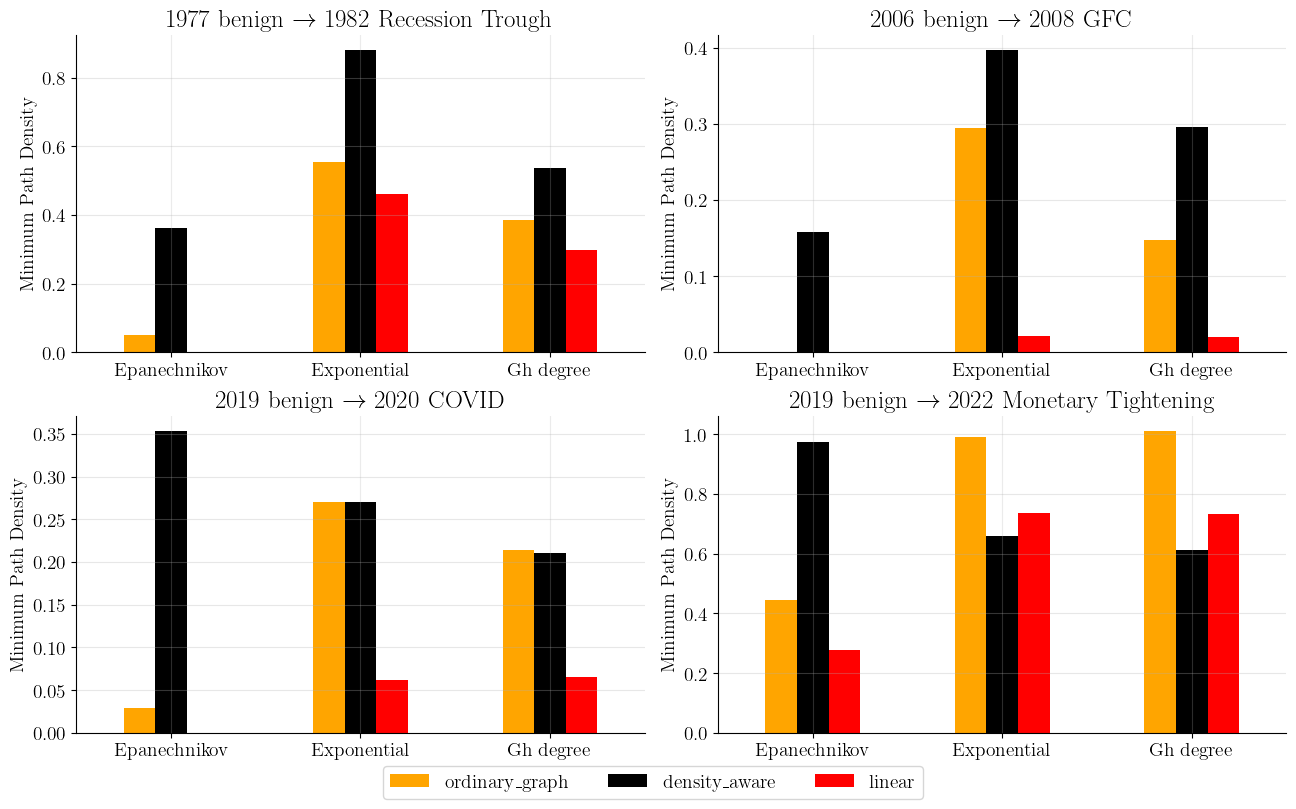

In [58]:
# Define your preferred order
path_order = ["ordinary_graph", "density_aware", "linear"]

# Convert 'path_type' to a ordered Categorical column
density_comparison_df["path_type"] = pd.Categorical(
    density_comparison_df["path_type"], 
    categories=path_order, 
    ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD)
axes_flat = axes.flatten()

for event, ax in zip(pairs.keys(), axes_flat):
    event_df = density_comparison_df[density_comparison_df["event"] == event]
    
    # Pivot will now automatically order columns: ordinary -> density-aware -> linear
    event_pivot = event_df.pivot(
        index="density_method", 
        columns="path_type", 
        values="interior_minimum_density"
    )

    plot_colours = [colour_map[col] for col in event_pivot.columns]
    
    event_pivot.plot(kind="bar", ax=ax, legend=False, color=plot_colours)
    
    ax.set_ylabel("Minimum Path Density")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=GRID_ALPHA)
    ax.set_title(event.replace("->", r"$\rightarrow$"), fontweight="bold")
    ax.tick_params(axis='x', labelrotation=0)

handles, labels = axes_flat[0].get_legend_handles_labels()

fig.legend(
    handles, 
    labels, 
    loc="lower center", 
    ncol=3, 
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.075, hspace=0.2)
plt.savefig(f'./figures/density_kernel_results.pdf')
plt.show()